In [1]:
"""
Earthquake Random Forest Model Training and Prediction
This notebook trains a Random Forest model on earthquake catalog data,
evaluates performance, and applies it to new datasets.
"""

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import joblib
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("=" * 80)
print("EARTHQUAKE RANDOM FOREST MODEL TRAINING AND PREDICTION")
print("=" * 80)


EARTHQUAKE RANDOM FOREST MODEL TRAINING AND PREDICTION


In [2]:

# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================
print("\n[STEP 1] Loading earthquake catalog data...")

# Load the training data
train_file = "/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_synthetic_catalog.csv"  
df = pd.read_csv(train_file)

print(f"✓ Data loaded successfully!")
print(f"  Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()



[STEP 1] Loading earthquake catalog data...
✓ Data loaded successfully!
  Shape: (100503, 20)

First few rows:


,event,DateTime,Date,Year,Month,Day,time,latitude,longitude,magnitude,Generation,ParentID,Label,i+,N+,T+,R+,dm+,n_child,n_parent
0,8,2005-01-01 01:10:00.825848852,2005-01-01,2005,1,1,0.048621,-37.396225,177.987203,3.301688,0,NaN,background,0,2.097547e-04,0.000694,3.021055e-01,0.176485,0.036315,0.036315
1,41,2005-01-01 05:42:37.953139645,2005-01-01,2005,1,1,0.237939,-37.124231,177.535453,3.163747,1,1754.0,triggered,1,2.702490e-05,0.003774,7.160450e-03,0.137941,0.036315,0.036315
2,46,2005-01-01 05:43:05.509842873,2005-01-01,2005,1,1,0.238258,-37.123676,177.537697,3.500583,1,1754.0,triggered,2,1.064500e-11,0.000007,1.421550e-06,-0.336836,0.072630,0.036315
3,47,2005-01-01 05:43:17.946950013,2005-01-01,2005,1,1,0.238402,-42.631090,167.284364,3.736844,0,NaN,background,3,1.811590e-06,0.000002,7.991986e-01,-0.236261,0.000000,0.072630
4,48,2005-01-01 05:43:23.387341987,2005-01-01,2005,1,1,0.238465,-37.123590,177.536278,3.048787,1,1754.0,triggered,3,1.428314e-12,0.000003,4.383602e-07,0.451797,0.036315,0.072630


In [3]:

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nBasic statistics:")
df.describe()


Column names:
['event', 'DateTime', 'Date', 'Year', 'Month', 'Day', 'time', 'latitude', 'longitude', 'magnitude', 'Generation', 'ParentID', 'Label', 'i+', 'N+', 'T+', 'R+', 'dm+', 'n_child', 'n_parent']

Data types:
event           int64
DateTime       object
Date           object
Year            int64
Month           int64
Day             int64
time          float64
latitude      float64
longitude     float64
magnitude     float64
Generation      int64
ParentID      float64
Label          object
i+              int64
N+            float64
T+            float64
R+            float64
dm+           float64
n_child       float64
n_parent      float64
dtype: object

Missing values:
event             0
DateTime          0
Date              0
Year              0
Month             0
Day               0
time              0
latitude          0
longitude         0
magnitude         0
Generation        0
ParentID      29671
Label             0
i+                0
N+                0
T+          

,event,Year,Month,Day,time,latitude,longitude,magnitude,Generation,ParentID,i+,N+,T+,R+,dm+,n_child,n_parent
count,1.005030e+05,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,70832.000000,100503.000000,1.005030e+05,1.005030e+05,1.005030e+05,100503.000000,100503.000000,100503.000000
mean,4.998227e+05,2009.473339,6.516014,15.753749,1815.951577,-40.491403,172.512215,3.433102,0.704775,8521.268142,48360.183756,6.997577e-06,4.996070e-02,9.138820e-03,1.092697,0.036315,10.996242
std,2.886813e+05,2.873401,3.433659,8.859918,1054.854397,3.759394,3.736498,0.433243,0.456146,4924.521953,29446.504210,1.587850e-05,5.344314e-01,5.344746e-02,1.490378,0.630884,40.608410
min,8.000000e+00,2005.000000,1.000000,1.000000,0.048621,-46.999943,166.000059,3.000005,0.000000,4.000000,0.000000,1.274211e-18,2.454859e-11,6.808480e-12,-3.696612,0.000000,0.036315
25%,2.506415e+05,2007.000000,4.000000,8.000000,901.201875,-43.809479,169.285313,3.125275,0.000000,4212.250000,20799.000000,2.606959e-12,1.564265e-05,1.058604e-07,0.042632,0.000000,0.072630
50%,5.005710e+05,2009.000000,7.000000,16.000000,1804.980886,-40.487934,172.497110,3.299426,1.000000,8540.000000,47630.000000,3.699105e-11,1.002774e-04,7.750077e-07,0.655338,0.000000,0.108945
75%,7.495705e+05,2012.000000,9.000000,23.000000,2732.180995,-37.203004,175.732346,3.599903,1.000000,12789.000000,74049.500000,6.556254e-06,2.537463e-03,6.221768e-04,1.877019,0.036315,0.472096
max,1.000027e+06,2014.000000,12.000000,31.000000,3649.777664,-34.000236,178.999147,8.128535,1.000000,17013.000000,100501.000000,2.960072e-04,4.988597e+01,2.086598e+00,5.128346,184.734973,184.734973


In [4]:

# ============================================================================
# STEP 2: DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 2] Data Preprocessing...")
print("=" * 80)

# Identify the label column (target variable)
# Common names: 'label', 'Label', 'class', 'Class', 'target', 'category'
label_columns = ['label', 'Label', 'class', 'Class', 'target', 'category', 'type', 'Type']
label_col = None

for col in label_columns:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    print("\n⚠ Could not automatically detect label column.")
    print(f"Available columns: {df.columns.tolist()}")
    label_col = input("Please enter the name of your label/target column: ")

print(f"\n✓ Using '{label_col}' as target variable")

# Check label distribution
print(f"\nLabel distribution:")
print(df[label_col].value_counts())



[STEP 2] Data Preprocessing...

✓ Using 'Label' as target variable

Label distribution:
Label
triggered     70832
background    29671
Name: count, dtype: int64


# Correlation Matrix

Label Distribution:
Label       Label_encoded
triggered   1                70832
background  0                29671
Name: count, dtype: int64



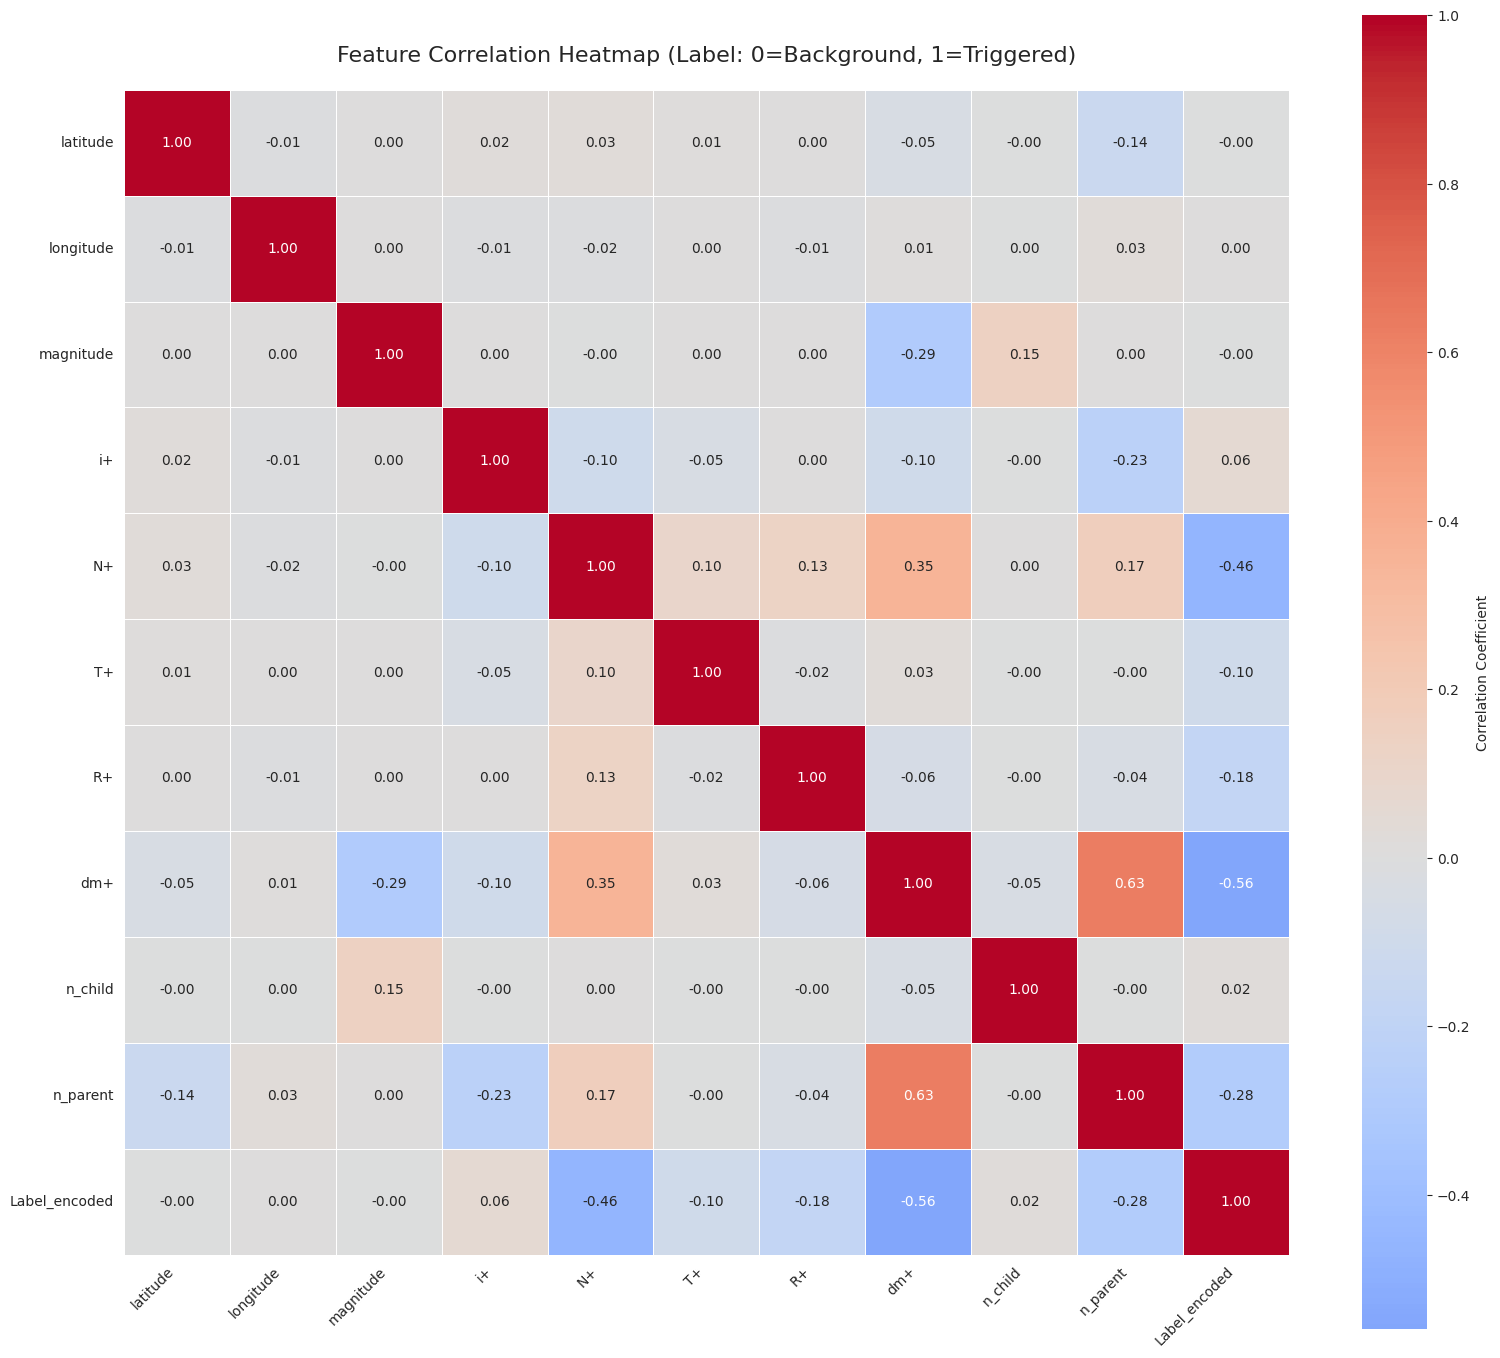

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df_encoded = df.copy()

# Encode Label: background=0, triggered=1 (or aftershock=1)
df_encoded['Label_encoded'] = df_encoded['Label'].map({'background': 0, 'triggered': 1})

# Check the encoding
print("Label Distribution:")
print(df_encoded[['Label', 'Label_encoded']].value_counts())
print()

# Select numeric columns including the encoded label
numeric_cols = ['latitude', 'longitude', 
                'magnitude', 'i+', 'N+', 'T+', 
                'R+', 'dm+', 'n_child', 'n_parent', 'Label_encoded']

# Calculate correlation matrix
correlation_matrix = df_encoded[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap (Label: 0=Background, 1=Triggered)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
print(df_encoded[numeric_cols].dtypes)
print(df_encoded[numeric_cols].isna().sum())


latitude         float64
longitude        float64
magnitude        float64
i+                 int64
N+               float64
T+               float64
R+               float64
dm+              float64
n_child          float64
n_parent         float64
Label_encoded      int64
dtype: object
latitude         0
longitude        0
magnitude        0
i+               0
N+               0
T+               0
R+               0
dm+              0
n_child          0
n_parent         0
Label_encoded    0
dtype: int64


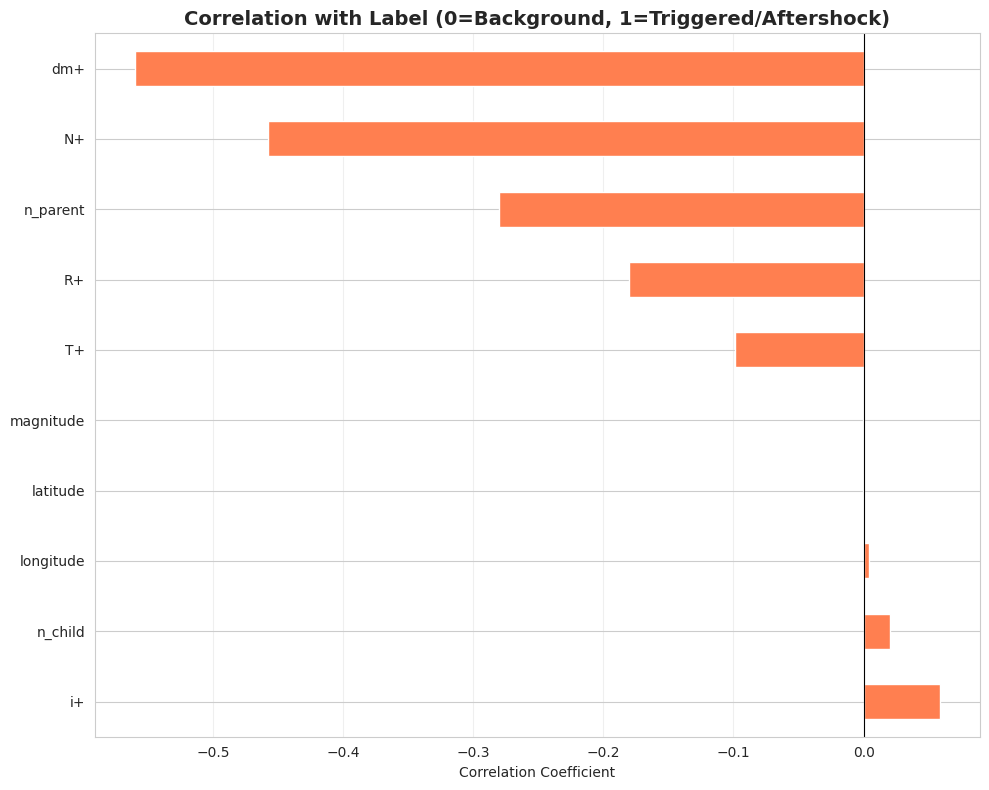

Correlations with Label (Background vs Triggered):
Label_encoded    1.000000
i+               0.058488
n_child          0.020560
longitude        0.004078
latitude        -0.000296
magnitude       -0.000383
T+              -0.099004
R+              -0.179938
n_parent        -0.279924
N+              -0.457913
dm+             -0.559624
Name: Label_encoded, dtype: float64



In [6]:
# Correlation with Label_encoded
label_corr = correlation_matrix['Label_encoded'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
label_corr[label_corr.index != 'Label_encoded'].plot(kind='barh', color='coral')
plt.title('Correlation with Label (0=Background, 1=Triggered/Aftershock)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlations with Label (Background vs Triggered):")
print(label_corr)
print()

In [7]:
# Compare features between background and triggered events
print("Feature Statistics by Label:")
print("="*70)

for col in ['magnitude', 'Generation', 'N+', 'T+', 'R+', 'dm+', 'n_child', 'n_parent']:
    print(f"\n{col}:")
    print(df_encoded.groupby('Label')[col].describe()[['mean', 'std', 'min', 'max']])

Feature Statistics by Label:

magnitude:
                mean       std       min       max
Label                                             
background  3.433359  0.433562  3.000011  7.868713
triggered   3.432995  0.433113  3.000005  8.128535

Generation:
            mean  std  min  max
Label                          
background   0.0  0.0  0.0  0.0
triggered    1.0  0.0  1.0  1.0

N+:
                mean       std           min       max
Label                                                 
background  0.000018  0.000021  3.079327e-10  0.000259
triggered   0.000002  0.000010  1.274211e-18  0.000296

T+:
                mean       std           min        max
Label                                                  
background  0.131712  0.900498  9.181192e-10  49.885966
triggered   0.015716  0.248228  2.454859e-11  30.801005

R+:
                mean       std           min       max
Label                                                 
background  0.023998  0.085639  1.180149e-08 

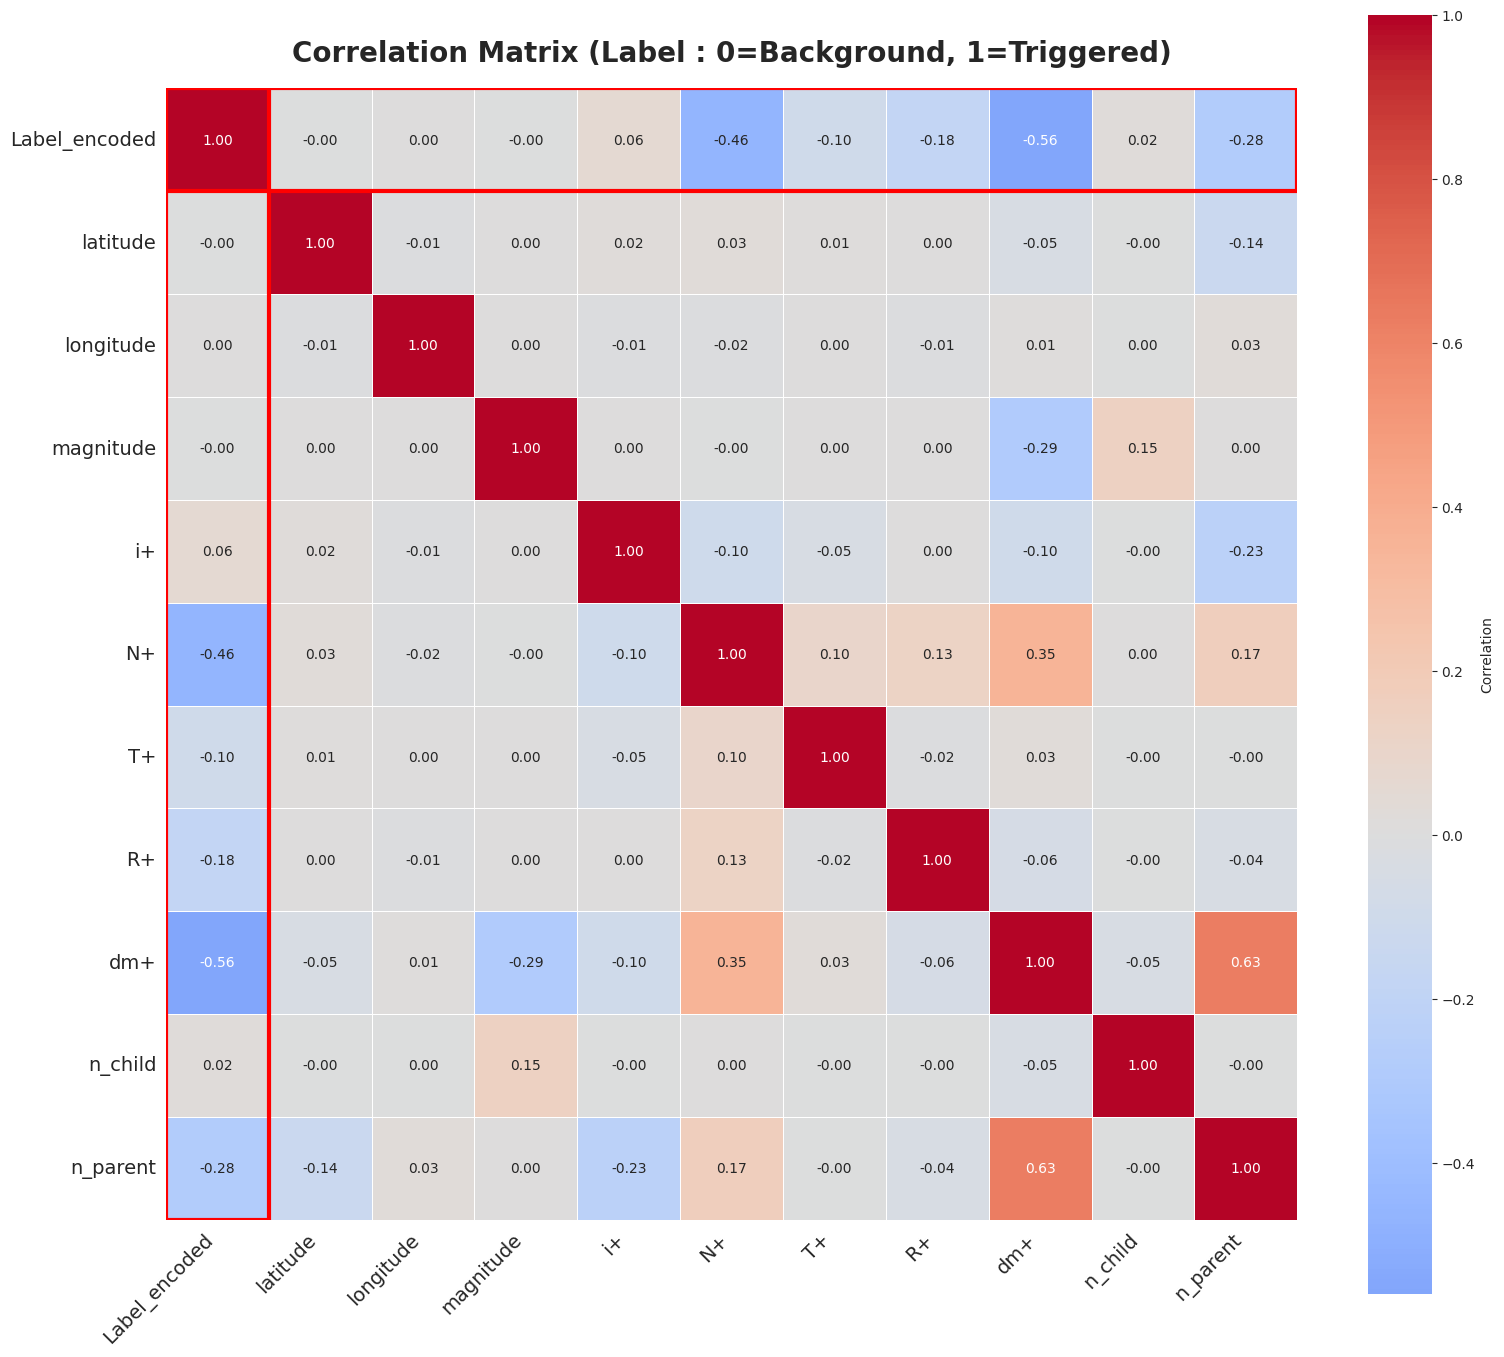

In [23]:
# Reorder columns to put Label_encoded first or last for emphasis
cols_reordered = ['Label_encoded'] + [col for col in numeric_cols if col != 'Label_encoded']
corr_reordered = df_encoded[cols_reordered].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_reordered, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix (Label : 0=Background, 1=Triggered)', 
          fontsize=20, fontweight='bold', pad=20)

# Make x-axis & y-axis labels bold and larger
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)

# Highlight Label row/column
ax = plt.gca()
ax.add_patch(plt.Rectangle((0, 0), len(cols_reordered), 1, fill=False, edgecolor='red', lw=3))
ax.add_patch(plt.Rectangle((0, 0), 1, len(cols_reordered), fill=False, edgecolor='red', lw=3))
plt.tight_layout()
plt.savefig("correlation_matrix.png_no_bold.png",dpi=900, bbox_inches='tight')

plt.show()


In [15]:

# Separate features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# Identify feature columns that match N+, R+, etc. pattern
feature_cols =  ['N+', 'R+', 'T+',  'dm+', 'n_child', 'n_parent']

if not feature_cols:
    # If no specific pattern found, use all numeric columns
    feature_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n✓ Selected features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Select only the feature columns
X = X[feature_cols]

# Handle missing values
if X.isnull().sum().sum() > 0:
    print(f"\n⚠ Handling {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median())
    print("✓ Missing values filled with median")

# Encode target variable if it's categorical
le = None
if y.dtype == 'object' or y.dtype.name == 'category':
    print(f"\n✓ Encoding target variable...")
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print(f"  Classes: {le.classes_}")
    y = pd.Series(y_encoded, index=y.index)
else:
    y_encoded = y


✓ Selected features (6):
  1. N+
  2. R+
  3. T+
  4. dm+
  5. n_child
  6. n_parent

✓ Encoding target variable...
  Classes: ['background' 'triggered']


In [16]:

# ============================================================================
# STEP 3: SPLIT DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 3] Splitting data into train and test sets...")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Data split completed!")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Features: {X_train.shape[1]}")



[STEP 3] Splitting data into train and test sets...
✓ Data split completed!
  Training set: 80402 samples
  Test set: 20101 samples
  Features: 6


In [17]:

# ============================================================================
# STEP 4: TRAIN RANDOM FOREST MODEL
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 4] Training Random Forest Classifier...")
print("=" * 80)

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='log2',
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("OOB Accuracy:", rf_model.oob_score_)

# Train the model
print("\nTraining in progress...")
rf_model.fit(X_train, y_train)
print("✓ Model training completed!")



[STEP 4] Training Random Forest Classifier...
OOB Accuracy: 0.9672147459018432

Training in progress...
✓ Model training completed!


In [15]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))
print("Cross-Val Accuracy:", cross_val_score(rf_model, X_train, y_train, cv=5).mean())


Train Accuracy: 0.97710255963782
Test Accuracy: 0.9702004875379334
Cross-Val Accuracy: 0.9672396235042683


In [22]:

# ============================================================================
# STEP 5: MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 5] Model Evaluation...")
print("=" * 80)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Determine if binary or multiclass
is_binary = len(np.unique(y)) == 2
average_method = 'binary' if is_binary else 'weighted'

precision = precision_score(y_test, y_test_pred, average=average_method, zero_division=0)
recall = recall_score(y_test, y_test_pred, average=average_method, zero_division=0)
f1 = f1_score(y_test, y_test_pred, average=average_method, zero_division=0)

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

# Print metrics
print("\n" + "=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Training Accuracy:        {train_accuracy:.4f}")
print(f"Test Accuracy:            {test_accuracy:.4f}")
print(f"Precision:                {precision:.4f}")
print(f"Recall:                   {recall:.4f}")
print(f"F1 Score:                 {f1:.4f}")
print(f"Cross-Val Accuracy:       {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Classification report
print("\n" + "=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
if le is not None:
    target_names = le.classes_
else:
    target_names = [f"Class {i}" for i in np.unique(y)]

print(classification_report(y_test, y_test_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)



[STEP 5] Model Evaluation...

MODEL PERFORMANCE METRICS
Training Accuracy:        0.9771
Test Accuracy:            0.9702
Precision:                0.9692
Recall:                   0.9892
F1 Score:                 0.9791
Cross-Val Accuracy:       0.9672 (+/- 0.0013)

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  background       0.97      0.92      0.95      5934
   triggered       0.97      0.99      0.98     14167

    accuracy                           0.97     20101
   macro avg       0.97      0.96      0.96     20101
weighted avg       0.97      0.97      0.97     20101


Confusion Matrix:
[[ 5488   446]
 [  153 14014]]


In [58]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))
print("Cross-Val Accuracy:", cross_val_score(rf_model, X_train, y_train, cv=5).mean())


Train Accuracy: 0.97710255963782
Test Accuracy: 0.9702004875379334
Cross-Val Accuracy: 0.9672396235042683


# Confusion Matrix

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Set publication-quality style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
labels = ['Background', 'Triggered']

# Calculate metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Normalize confusion matrix for percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# ============================================
# Main Confusion Matrix with both counts and percentages
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Number of samples'},
            linewidths=2, linecolor='white',
            square=True, ax=ax, vmin=0)

# Add custom annotations with counts and percentages
for i in range(len(labels)):
    for j in range(len(labels)):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        
        # Determine text color for readability
        text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        
        # Add count and percentage
        ax.text(j + 0.5, i + 0.5, f'{count}\n({percentage:.1f}%)',
                ha='center', va='center', 
                fontsize=14, fontweight='bold', color=text_color)

# Labels and title
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - Random Forest Classifier',
             fontsize=13, fontweight='bold', pad=15)

# Format tick labels
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')  
plt.show()



NameError: name 'y_test_pred' is not defined

In [23]:

# ============================================================================
# STEP 6: CREATE OUTPUT DIRECTORY AND SAVE RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 6] Saving Model and Results...")
print("=" * 80)

# Create output directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"rf_model_{timestamp}"
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Created directory: {output_dir}")

# Save the model
model_path = os.path.join(output_dir, "random_forest_model.pkl")
joblib.dump(rf_model, model_path)
print(f"✓ Saved model to: {model_path}")

# Save the label encoder if used
if le is not None:
    le_path = os.path.join(output_dir, "label_encoder.pkl")
    joblib.dump(le, le_path)
    print(f"✓ Saved label encoder to: {le_path}")

# Save feature names
feature_names_path = os.path.join(output_dir, "feature_names.pkl")
joblib.dump(feature_cols, feature_names_path)
print(f"✓ Saved feature names to: {feature_names_path}")

# Save metrics to text file
metrics_path = os.path.join(output_dir, "model_metrics.txt")
with open(metrics_path, 'w') as f:
    f.write("EARTHQUAKE RANDOM FOREST MODEL - PERFORMANCE METRICS\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Model trained on: {timestamp}\n")
    f.write(f"Training samples: {X_train.shape[0]}\n")
    f.write(f"Test samples: {X_test.shape[0]}\n")
    f.write(f"Number of features: {X_train.shape[1]}\n\n")
    f.write("PERFORMANCE METRICS:\n")
    f.write("-" * 70 + "\n")
    f.write(f"Training Accuracy:        {train_accuracy:.4f}\n")
    f.write(f"Test Accuracy:            {test_accuracy:.4f}\n")
    f.write(f"Precision:                {precision:.4f}\n")
    f.write(f"Recall:                   {recall:.4f}\n")
    f.write(f"F1 Score:                 {f1:.4f}\n")
    f.write(f"Cross-Val Accuracy:       {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n\n")
    f.write("CLASSIFICATION REPORT:\n")
    f.write("-" * 70 + "\n")
    f.write(classification_report(y_test, y_test_pred, target_names=target_names))
    f.write("\n\nCONFUSION MATRIX:\n")
    f.write("-" * 70 + "\n")
    f.write(str(cm))

print(f"✓ Saved metrics to: {metrics_path}")

# Save predictions
predictions_df = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_test_pred
})
if le is not None:
    predictions_df['True_Label_Name'] = le.inverse_transform(y_test.values)
    predictions_df['Predicted_Label_Name'] = le.inverse_transform(y_test_pred)

predictions_path = os.path.join(output_dir, "test_predictions.csv")
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Saved predictions to: {predictions_path}")



[STEP 6] Saving Model and Results...
✓ Created directory: rf_model_20251109_215442
✓ Saved model to: rf_model_20251109_215442/random_forest_model.pkl
✓ Saved label encoder to: rf_model_20251109_215442/label_encoder.pkl
✓ Saved feature names to: rf_model_20251109_215442/feature_names.pkl
✓ Saved metrics to: rf_model_20251109_215442/model_metrics.txt
✓ Saved predictions to: rf_model_20251109_215442/test_predictions.csv



[STEP 7] Creating Visualizations...
✓ Saved performance plots to: rf_model_20251108_190748/model_performance_plots.png


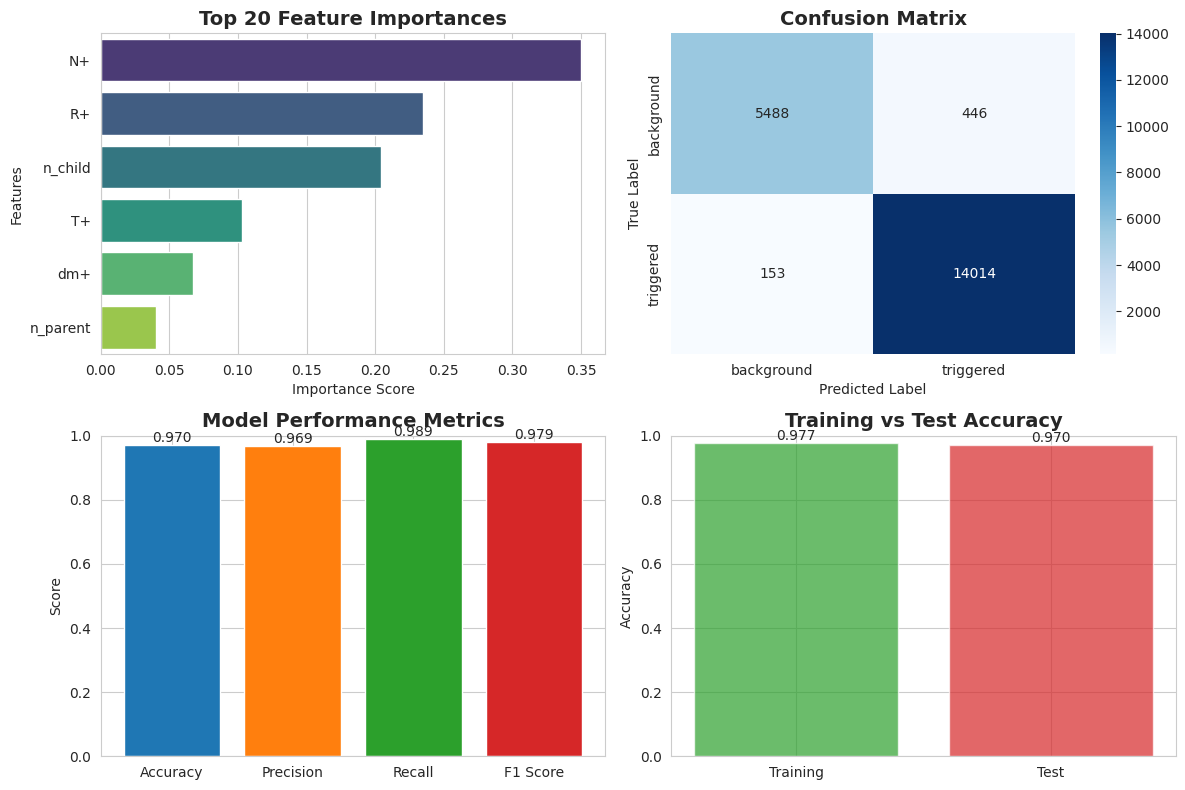

✓ Saved detailed feature importance to: rf_model_20251108_190748/feature_importance_detailed.png


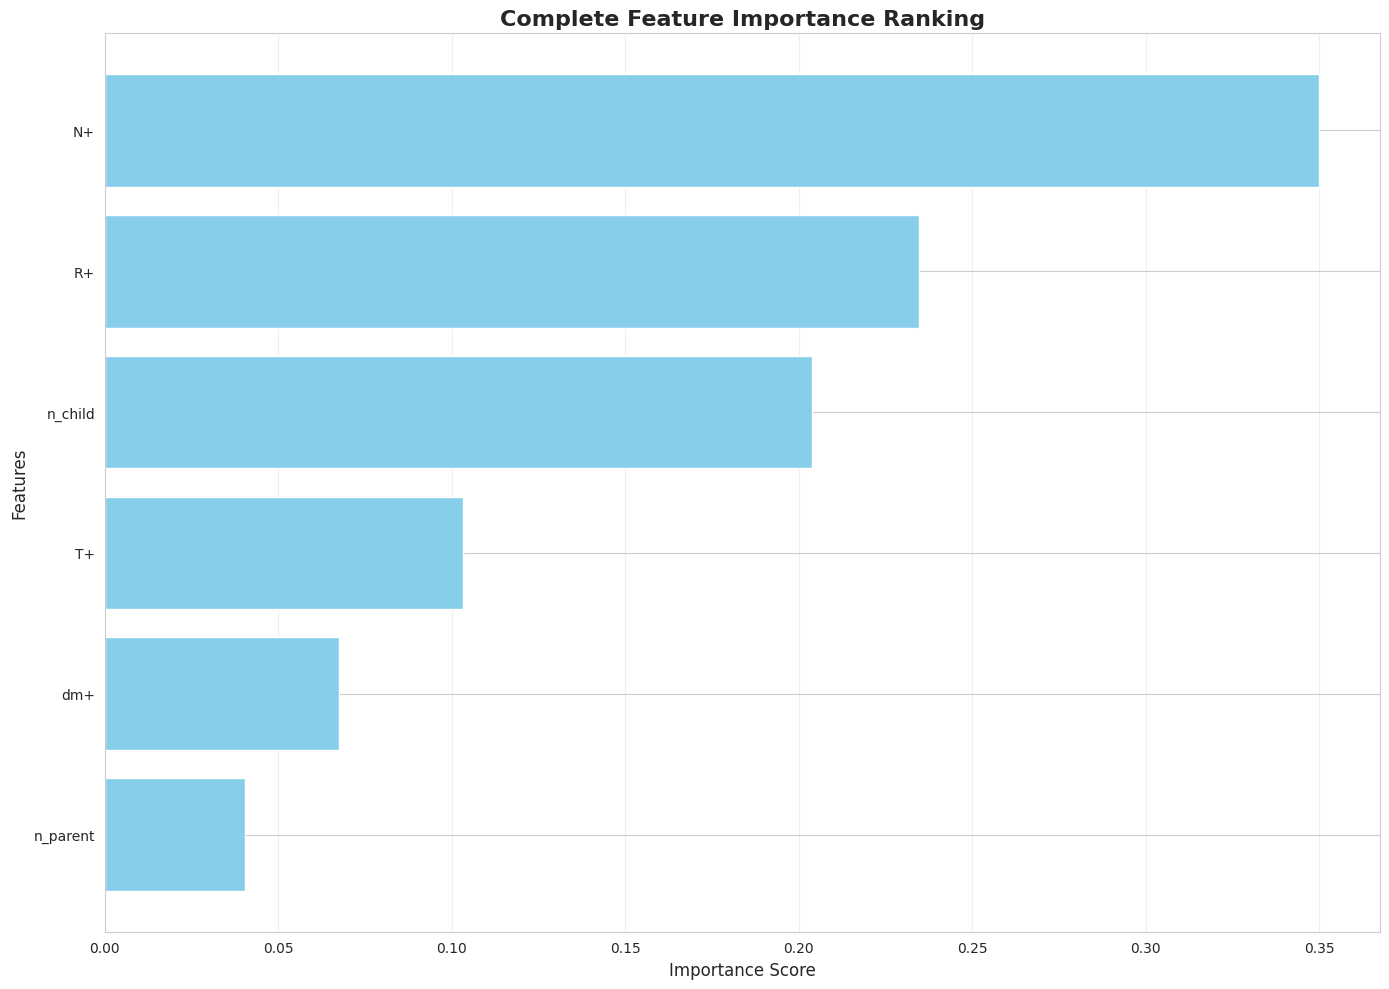

✓ Saved feature importance data to: rf_model_20251108_190748/feature_importance.csv


In [20]:

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 7] Creating Visualizations...")
print("=" * 80)

# 1. Feature Importance Plot
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.subplot(2, 2, 1)
sns.barplot(data=feature_importance.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# 2. Confusion Matrix Heatmap
plt.subplot(2, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 3. Model Performance Comparison
plt.subplot(2, 2, 3)
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [test_accuracy, precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_data)
bars = plt.bar(metrics_df['Metric'], metrics_df['Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim(0, 1)
plt.title('Model Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom')

# 4. Training vs Test Accuracy
plt.subplot(2, 2, 4)
accuracy_comparison = pd.DataFrame({
    'Dataset': ['Training', 'Test'],
    'Accuracy': [train_accuracy, test_accuracy]
})
bars = plt.bar(accuracy_comparison['Dataset'], accuracy_comparison['Accuracy'], 
               color=['#2ca02c', '#d62728'], alpha=0.7)
plt.ylim(0, 1)
plt.title('Training vs Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plot_path = os.path.join(output_dir, "model_performance_plots.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved performance plots to: {plot_path}")
plt.show()

# Detailed Feature Importance Plot
plt.figure(figsize=(14, 10))
plt.barh(range(len(feature_importance)), feature_importance['importance'], color='skyblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Complete Feature Importance Ranking', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
feat_imp_path = os.path.join(output_dir, "feature_importance_detailed.png")
plt.savefig(feat_imp_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved detailed feature importance to: {feat_imp_path}")
plt.show()

# Save feature importance to CSV
feat_imp_csv = os.path.join(output_dir, "feature_importance.csv")
feature_importance.to_csv(feat_imp_csv, index=False)
print(f"✓ Saved feature importance data to: {feat_imp_csv}")

# Apply model to the new data

In [24]:


# ============================================================================
# STEP 8: APPLY MODEL TO NEW DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 8] Applying Model to New Dataset...")
print("=" * 80)

# Load new data (you'll need to provide this file)
new_data_file_entire = "/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv"  # Replace with your new data file
new_df = pd.read_csv(new_data_file_entire)
new_df.head()


[STEP 8] Applying Model to New Dataset...


,event,date,Time,latitude,longitude,depth,magnitude,DateTime,time,Year,...,Hour,Minute,Second,i+,N+,T+,R+,dm+,n_child,n_parent
0,2,1980-01-01,09:27:04.52,-40.490,174.66901,72.6,3.200,1980-01-01 09:27:04.520,0.099293,1980,...,9,27,4.52,0,0.000217,0.004731,0.045941,-0.633,0.082958,0.041479
1,3,1980-01-01,18:28:10.99,-37.630,176.38000,210.0,4.150,1980-01-01 18:28:10.990,0.475062,1980,...,18,28,10.99,1,0.001304,0.008451,0.154341,-0.950,0.124437,0.082958
2,4,1980-01-01,20:20:54.03,-40.290,173.42999,212.0,4.500,1980-01-01 20:20:54.030,0.553338,1980,...,20,20,54.03,2,0.000038,0.000571,0.066251,-0.350,0.165915,0.124437
3,5,1980-01-02,18:24:15.40,-38.480,176.75000,5.0,3.375,1980-01-02 18:24:15.400,1.472336,1980,...,18,24,15.40,2,0.000047,0.007270,0.006458,0.775,0.000000,0.124437
4,6,1980-01-04,01:21:41.06,-40.906,175.23700,24.1,2.750,1980-01-04 01:21:41.060,2.762216,1980,...,1,21,41.06,3,0.000144,0.010633,0.013547,1.750,0.041479,0.165915


In [20]:
# Create output directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"entire_nz_rf_model_{timestamp}"
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Created directory: {output_dir}")


✓ Created directory: entire_nz_rf_model_20251109_215259


In [25]:


# ============================================================================
# STEP 8: APPLY MODEL TO NEW DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 8] Applying Model to New Dataset...")
print("=" * 80)

# Load new data (you'll need to provide this file)
new_data_file = "/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv"  # Replace with your new data file

try:
    print(f"\nAttempting to load: {new_data_file}")
    new_df = pd.read_csv(new_data_file)
    print(f"✓ New data loaded successfully!")
    print(f"  Shape: {new_df.shape}")
    
    # Extract features matching the training data
    missing_features = [f for f in feature_cols if f not in new_df.columns]
    if missing_features:
        print(f"\n⚠ Warning: Missing features in new data: {missing_features}")
        print("  These will be filled with 0")
        for feat in missing_features:
            new_df[feat] = 0
    
    X_new = new_df[feature_cols]
    
    # Handle missing values
    if X_new.isnull().sum().sum() > 0:
        print(f"⚠ Handling {X_new.isnull().sum().sum()} missing values in new data...")
        X_new = X_new.fillna(X_new.median())
    
    # Make predictions
    print("\nMaking predictions on new data...")
    y_new_pred = rf_model.predict(X_new)
    y_new_proba = rf_model.predict_proba(X_new)
    
    # Create results dataframe
    results_df = new_df.copy()
    results_df['Predicted_Label'] = y_new_pred
    
    if le is not None:
        results_df['Predicted_Label_Name'] = le.inverse_transform(y_new_pred)
    
    # Add probability columns
    for i, class_name in enumerate(target_names):
        results_df[f'Probability_{class_name}'] = y_new_proba[:, i]
    
    # Save predictions
    new_predictions_path = os.path.join(output_dir, "Entire_nz_prediction_rf.csv")
    results_df.to_csv(new_predictions_path, index=False)
    print(f"✓ Saved new predictions to: {new_predictions_path}")
    
    # Print summary
    print("\n" + "=" * 50)
    print("NEW DATA PREDICTION SUMMARY")
    print("=" * 50)
    print(f"Total predictions: {len(y_new_pred)}")
    print("\nPredicted label distribution:")
    if le is not None:
        pred_counts = pd.Series(le.inverse_transform(y_new_pred)).value_counts()
    else:
        pred_counts = pd.Series(y_new_pred).value_counts()
    print(pred_counts)
    
except FileNotFoundError:
    print(f"\n⚠ File '{new_data_file}' not found.")
    print("  To use the model on new data:")
    print("  1. Prepare a CSV file with the same features as training data")
    print("  2. Update the 'new_data_file' variable with your file path")
    print("  3. Run this cell again")
except Exception as e:
    print(f"\n❌ Error processing new data: {str(e)}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"\n📁 All outputs saved to: {output_dir}/")
print("\n📊 Files created:")
print(f"  ✓ random_forest_model.pkl - Trained model")
print(f"  ✓ label_encoder.pkl - Label encoder (if applicable)")
print(f"  ✓ feature_names.pkl - Feature names")
print(f"  ✓ model_metrics.txt - Performance metrics")
print(f"  ✓ test_predictions.csv - Test set predictions")
print(f"  ✓ feature_importance.csv - Feature importance data")
print(f"  ✓ model_performance_plots.png - Visualization plots")
print(f"  ✓ feature_importance_detailed.png - Detailed feature importance")
if os.path.exists(os.path.join(output_dir, "new_data_predictions.csv")):
    print(f"  ✓ new_data_predictions.csv - New data predictions")

print("\n" + "=" * 80)
print("To use the model later:")
print("=" * 80)
print("""
# Load the saved model
import joblib
loaded_model = joblib.load('path/to/random_forest_model.pkl')
loaded_features = joblib.load('path/to/feature_names.pkl')
loaded_encoder = joblib.load('path/to/label_encoder.pkl')

# Make predictions on new data
predictions = loaded_model.predict(new_data[loaded_features])
predicted_labels = loaded_encoder.inverse_transform(predictions)
""")


[STEP 8] Applying Model to New Dataset...

Attempting to load: /home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv
✓ New data loaded successfully!
  Shape: (396267, 22)

Making predictions on new data...
✓ Saved new predictions to: rf_model_20251109_215442/Entire_nz_prediction_rf.csv

NEW DATA PREDICTION SUMMARY
Total predictions: 396267

Predicted label distribution:
background    272671
triggered     123596
Name: count, dtype: int64

TRAINING COMPLETE!

📁 All outputs saved to: rf_model_20251109_215442/

📊 Files created:
  ✓ random_forest_model.pkl - Trained model
  ✓ label_encoder.pkl - Label encoder (if applicable)
  ✓ feature_names.pkl - Feature names
  ✓ model_metrics.txt - Performance metrics
  ✓ test_predictions.csv - Test set predictions
  ✓ feature_importance.csv - Feature importance data
  ✓ model_performance_plots.png - Visualization plots
  ✓ feature_importance_detailed.png - Detailed feature importance

To use the model later:

# Load the saved mode

# END ENTIRE DATASET TESTING

In [ ]:


# ============================================================================
# STEP 8: APPLY MODEL TO NEW DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 8] Applying Model to New Dataset...")
print("=" * 80)

# Load new data (you'll need to provide this file)
new_data_file = "/home/ashraf/Desktop/THESIS-FINAL/DATA/mld_test-nz.csv"  # Replace with your new data file
new_df = pd.read_csv(new_data_file)
new_df.head()


[STEP 8] Applying Model to New Dataset...


,event,time,latitude,longitude,magnitude,i+,N+,T+,R+,dm+,n_child,n_parent
0,3,0.475062,-37.63,176.38000,4.150,0,0.001304,0.008451,0.154341,-0.950,0.517447,0.129362
1,4,0.553338,-40.29,173.42999,4.500,1,0.000038,0.000571,0.066251,-0.350,0.258723,0.517447
2,5,1.472336,-38.48,176.75000,3.375,1,0.000047,0.007270,0.006458,0.775,0.000000,0.517447
3,7,2.766910,-36.66,177.45000,4.818,1,0.000219,0.016708,0.013127,-0.668,1.552340,0.517447
4,8,2.809132,-38.71,175.94000,4.011,4,0.000002,0.000139,0.014728,0.807,0.258723,1.552340


In [22]:


# ============================================================================
# STEP 8: APPLY MODEL TO NEW DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 8] Applying Model to New Dataset...")
print("=" * 80)

# Load new data (you'll need to provide this file)
new_data_file = "/home/ashraf/Desktop/THESIS-FINAL/DATA/mld_test-nz.csv"  # Replace with your new data file

try:
    print(f"\nAttempting to load: {new_data_file}")
    new_df = pd.read_csv(new_data_file)
    print(f"✓ New data loaded successfully!")
    print(f"  Shape: {new_df.shape}")
    
    # Extract features matching the training data
    missing_features = [f for f in feature_cols if f not in new_df.columns]
    if missing_features:
        print(f"\n⚠ Warning: Missing features in new data: {missing_features}")
        print("  These will be filled with 0")
        for feat in missing_features:
            new_df[feat] = 0
    
    X_new = new_df[feature_cols]
    
    # Handle missing values
    if X_new.isnull().sum().sum() > 0:
        print(f"⚠ Handling {X_new.isnull().sum().sum()} missing values in new data...")
        X_new = X_new.fillna(X_new.median())
    
    # Make predictions
    print("\nMaking predictions on new data...")
    y_new_pred = rf_model.predict(X_new)
    y_new_proba = rf_model.predict_proba(X_new)
    
    # Create results dataframe
    results_df = new_df.copy()
    results_df['Predicted_Label'] = y_new_pred
    
    if le is not None:
        results_df['Predicted_Label_Name'] = le.inverse_transform(y_new_pred)
    
    # Add probability columns
    for i, class_name in enumerate(target_names):
        results_df[f'Probability_{class_name}'] = y_new_proba[:, i]
    
    # Save predictions
    new_predictions_path = os.path.join(output_dir, "new_data_predictions.csv")
    results_df.to_csv(new_predictions_path, index=False)
    print(f"✓ Saved new predictions to: {new_predictions_path}")
    
    # Print summary
    print("\n" + "=" * 50)
    print("NEW DATA PREDICTION SUMMARY")
    print("=" * 50)
    print(f"Total predictions: {len(y_new_pred)}")
    print("\nPredicted label distribution:")
    if le is not None:
        pred_counts = pd.Series(le.inverse_transform(y_new_pred)).value_counts()
    else:
        pred_counts = pd.Series(y_new_pred).value_counts()
    print(pred_counts)
    
except FileNotFoundError:
    print(f"\n⚠ File '{new_data_file}' not found.")
    print("  To use the model on new data:")
    print("  1. Prepare a CSV file with the same features as training data")
    print("  2. Update the 'new_data_file' variable with your file path")
    print("  3. Run this cell again")
except Exception as e:
    print(f"\n❌ Error processing new data: {str(e)}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"\n📁 All outputs saved to: {output_dir}/")
print("\n📊 Files created:")
print(f"  ✓ random_forest_model.pkl - Trained model")
print(f"  ✓ label_encoder.pkl - Label encoder (if applicable)")
print(f"  ✓ feature_names.pkl - Feature names")
print(f"  ✓ model_metrics.txt - Performance metrics")
print(f"  ✓ test_predictions.csv - Test set predictions")
print(f"  ✓ feature_importance.csv - Feature importance data")
print(f"  ✓ model_performance_plots.png - Visualization plots")
print(f"  ✓ feature_importance_detailed.png - Detailed feature importance")
if os.path.exists(os.path.join(output_dir, "new_data_predictions.csv")):
    print(f"  ✓ new_data_predictions.csv - New data predictions")

print("\n" + "=" * 80)
print("To use the model later:")
print("=" * 80)
print("""
# Load the saved model
import joblib
loaded_model = joblib.load('path/to/random_forest_model.pkl')
loaded_features = joblib.load('path/to/feature_names.pkl')
loaded_encoder = joblib.load('path/to/label_encoder.pkl')

# Make predictions on new data
predictions = loaded_model.predict(new_data[loaded_features])
predicted_labels = loaded_encoder.inverse_transform(predictions)
""")


[STEP 8] Applying Model to New Dataset...

Attempting to load: /home/ashraf/Desktop/THESIS-FINAL/DATA/mld_test-nz.csv
✓ New data loaded successfully!
  Shape: (127060, 12)

Making predictions on new data...
✓ Saved new predictions to: rf_model_20251108_190748/new_data_predictions.csv

NEW DATA PREDICTION SUMMARY
Total predictions: 127060

Predicted label distribution:
background    76462
triggered     50598
Name: count, dtype: int64

TRAINING COMPLETE!

📁 All outputs saved to: rf_model_20251108_190748/

📊 Files created:
  ✓ random_forest_model.pkl - Trained model
  ✓ label_encoder.pkl - Label encoder (if applicable)
  ✓ feature_names.pkl - Feature names
  ✓ model_metrics.txt - Performance metrics
  ✓ test_predictions.csv - Test set predictions
  ✓ feature_importance.csv - Feature importance data
  ✓ model_performance_plots.png - Visualization plots
  ✓ feature_importance_detailed.png - Detailed feature importance
  ✓ new_data_predictions.csv - New data predictions

To use the model la

In [23]:
print("\n=== PREDICTION SUMMARY ===")

# Distribution of predicted labels
pred_counts = results_df['Predicted_Label'].value_counts()
total = pred_counts.sum()

print("\nPredicted Label Distribution:")
for label, count in pred_counts.items():
    percent = (count / total) * 100
    label_name = le.inverse_transform([label])[0] if le else label
    print(f"  {label_name}: {count} ({percent:.2f}%)")

# Average model confidence per class
if 'Probability_background' in results_df.columns:
    prob_cols = [c for c in results_df.columns if c.startswith('Probability_')]
    avg_confidence = results_df[prob_cols].mean()
    print("\nAverage Confidence per Class:")
    print(avg_confidence)



=== PREDICTION SUMMARY ===

Predicted Label Distribution:
  background: 76462 (60.18%)
  triggered: 50598 (39.82%)

Average Confidence per Class:
Probability_background    0.645488
Probability_triggered     0.354512
dtype: float64


# Plot from Prediction data

Loading prediction results from: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251108_190748/new_data_predictions.csv


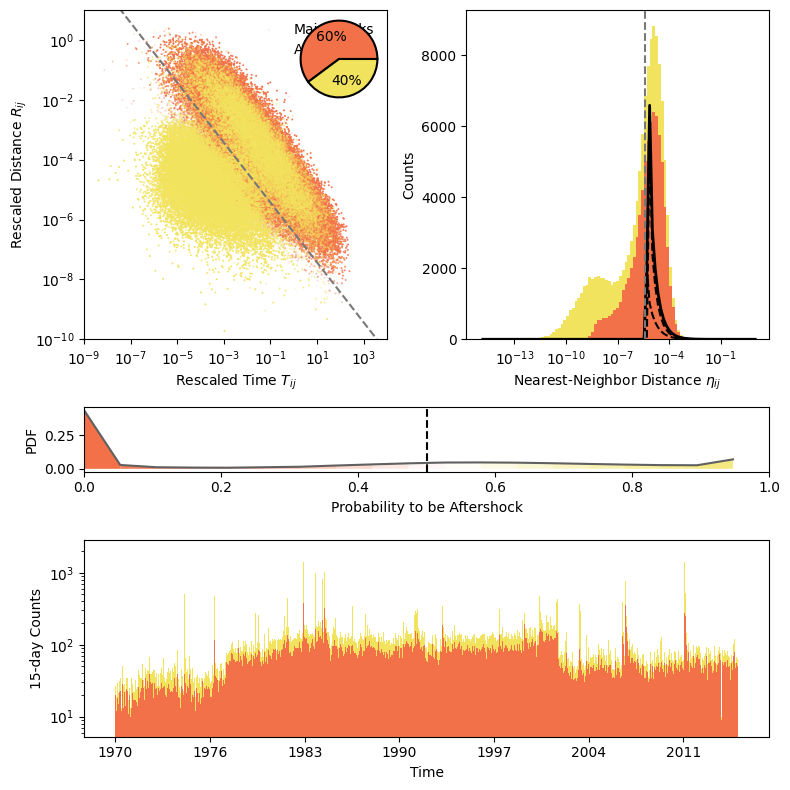

✅ Plot saved as RF_predictions_from_csv.png


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mc
from scipy.optimize import minimize
from matplotlib.font_manager import FontProperties

# -----------------------
# Distribution fit functions
# -----------------------
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

def weibull(x, x0, a, lambda_, k):
    z = (x - x0) / lambda_
    z[z <= 0] = 1e-10
    y = (k / lambda_) * (z ** (k - 1)) * np.exp(-(z ** k))
    y[x < x0] = 0
    return a * y

def objfun_weibull(params, x, y):
    x0, a, lambda_, k = params
    f_theo = weibull(x, x0, a, lambda_, k)
    return np.sqrt(np.mean((y - f_theo) ** 2))

# -----------------------
# Main plotting function
# -----------------------
def plot_from_prediction_csv(prediction_csv, figure_name='RF_predictions_from_csv.png', dt=15):
    print(f"Loading prediction results from: {prediction_csv}")
    df = pd.read_csv(prediction_csv)

    # Identify probability column
    prob_col = None
    for c in df.columns:
        if "Probability" in c and "triggered" in c:
            prob_col = c
            break
    if prob_col is None:
        raise ValueError("❌ No aftershock probability column found (expected something like 'Probability_triggered').")

    prob = df[prob_col].values
    pred = np.round(prob)  # 0 = background, 1 = aftershock

    # Filter missing or invalid N+ values
    if 'N+' not in df.columns:
        raise ValueError("❌ Column 'N+' not found in data!")
    main_N = df.loc[pred == 0, 'N+']
    after_N = df.loc[pred == 1, 'N+']
    main_N = main_N[main_N > 0]
    after_N = after_N[after_N > 0]

    # Weibull fits
    hb, bins = np.histogram(np.log10(main_N), np.linspace(-15, 1, 100))
    pm = minimize(objfun_weibull, x0=(-8, 500, 6, 8), args=(bins[:-1], hb))
    x = bins[0] + np.cumsum(np.diff(bins))
    fit_main = weibull(x, *pm.x)

    ha, _ = np.histogram(np.log10(after_N), bins=bins)
    pa = minimize(objfun_weibull, x0=(-12, 500, 6, 8), args=(bins[:-1], ha))
    fit_after = weibull(x, *pa.x)

    # Create figure
    fig = plt.figure(figsize=(8, 8))
    gs = fig.add_gridspec(6, 2)
    ax1 = fig.add_subplot(gs[:3, 0])
    ax2 = fig.add_subplot(gs[:3, 1])
    ax3 = fig.add_subplot(gs[3, :])
    ax4 = fig.add_subplot(gs[4:, :])
    pie1 = fig.add_axes([0.37, 0.86, 0.12, 0.12])

    # Colors
    color_main = '#f27149'
    color_after = '#f2e35e'
    cmap_main = mc.LinearSegmentedColormap.from_list('main', [(0, (*mc.to_rgb(color_main), 0)), (1, color_main)])
    cmap_after = mc.LinearSegmentedColormap.from_list('after', [(0, (*mc.to_rgb(color_after), 0)), (1, color_after)])

    # -----------------------
    # Scatter: Rescaled distance vs time
    # -----------------------
    if {'T+', 'R+'}.issubset(df.columns):
        ax1.scatter(df.loc[pred == 0, 'T+'], df.loc[pred == 0, 'R+'],
                    s=2, c=1 - prob[pred == 0], cmap=cmap_main, ec='None')
        ax1.scatter(df.loc[pred == 1, 'T+'], df.loc[pred == 1, 'R+'],
                    s=2, c=prob[pred == 1], cmap=cmap_after, ec='None')
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(1e-9, 1e4)
        ax1.set_ylim(1e-10, 10)
        ax1.set_xlabel(r'Rescaled Time $T_{ij}$')
        ax1.set_ylabel(r'Rescaled Distance $R_{ij}$')
        ax1.legend(['Mainshocks', 'Aftershocks'], frameon=False)
    # Reference threshold line (separation boundary)
        threshold = 3.7e-7
        tij = np.array([1e-9, 1e4], dtype=float)
        rij = threshold / tij
        ax1.plot(tij, rij, '--', c='#787878', label='Separation line')

       
    # -----------------------
    # Histogram of N+
    # -----------------------
    ax2.hist([df.loc[pred == 0, 'N+'], df.loc[pred == 1, 'N+']],
             bins=10 ** np.linspace(-15, 1, 100),
             stacked=True, color=[color_main, color_after])
    ax2.semilogx(10 ** x, fit_main, 'k--')
    ax2.semilogx(10 ** x, fit_after, 'k--')
    ax2.semilogx(10 ** x, fit_after + fit_main, 'k-', lw=2)
    ax2.axvline(3.7e-6, ls='--', c='#787878')
    ax2.set_xlabel(r'Nearest-Neighbor Distance $\eta_{ij}$')
    ax2.set_ylabel('Counts')

    # -----------------------
    # Probability distribution
    # -----------------------
    h, bins_prob = np.histogram(prob, bins=np.linspace(0, 1, 20))
    h = h / h.sum()
    bins_prob = bins_prob[:-1]
    ax3.plot(bins_prob, h, c='#606060')
    for i in range(len(bins_prob) - 1):
        b = bins_prob[i:i + 2]
        h_ = h[i:i + 2]
        if b[0] <= 0.5:
            color = color_main
            alpha = 1 - b[0] / 0.5
        else:
            color = color_after
            alpha = (b[0] - 0.5) / 0.5
        ax3.fill_between(b, h_, fc=color, ec='None', alpha=alpha)
    ax3.axvline(0.5, linestyle='--', color='k')
    ax3.set_xlim(0, 1)
    ax3.set_xlabel('Probability to be Aftershock')
    ax3.set_ylabel('PDF')

    # -----------------------
    # Histogram through time
    # -----------------------
    if 'time' in df.columns:
        bins_time = np.arange(int(df.time.min()), int(df.time.max()) + dt, dt)
        ax4.hist([df.loc[pred == 0, 'time'], df.loc[pred == 1, 'time']],
                 bins=bins_time, stacked=True, color=[color_main, color_after])
        ax4.set_yscale('log')
        ax4.set_ylabel(f'{dt}-day Counts')
        ax4.set_xlabel('Time')
        ax4.xaxis.set_major_formatter(md.DateFormatter('%Y'))

    # -----------------------
    # Pie chart
    # -----------------------
    n_bg, n_af = (pred == 0).sum(), (pred == 1).sum()
    pie1.pie([n_bg, n_af], colors=[color_main, color_after],
             autopct='%.0f%%', wedgeprops={"edgecolor": "k", 'linewidth': 1.5})
    
    plt.tight_layout()
    #plt.savefig(figure_name, dpi=300)
    plt.show()
    #plt.close()
    print(f"✅ Plot saved as {figure_name}")
    
# -----------------------
# Run Example
# -----------------------
if __name__ == "__main__":
    plot_from_prediction_csv("/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251108_190748/new_data_predictions.csv")
    plt.show()

📂 Loading: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251108_190748/new_data_predictions.csv
📊 Background events: 76462 | Aftershock events: 49573
✅ Plot saved as RF_predictions_landscape.png


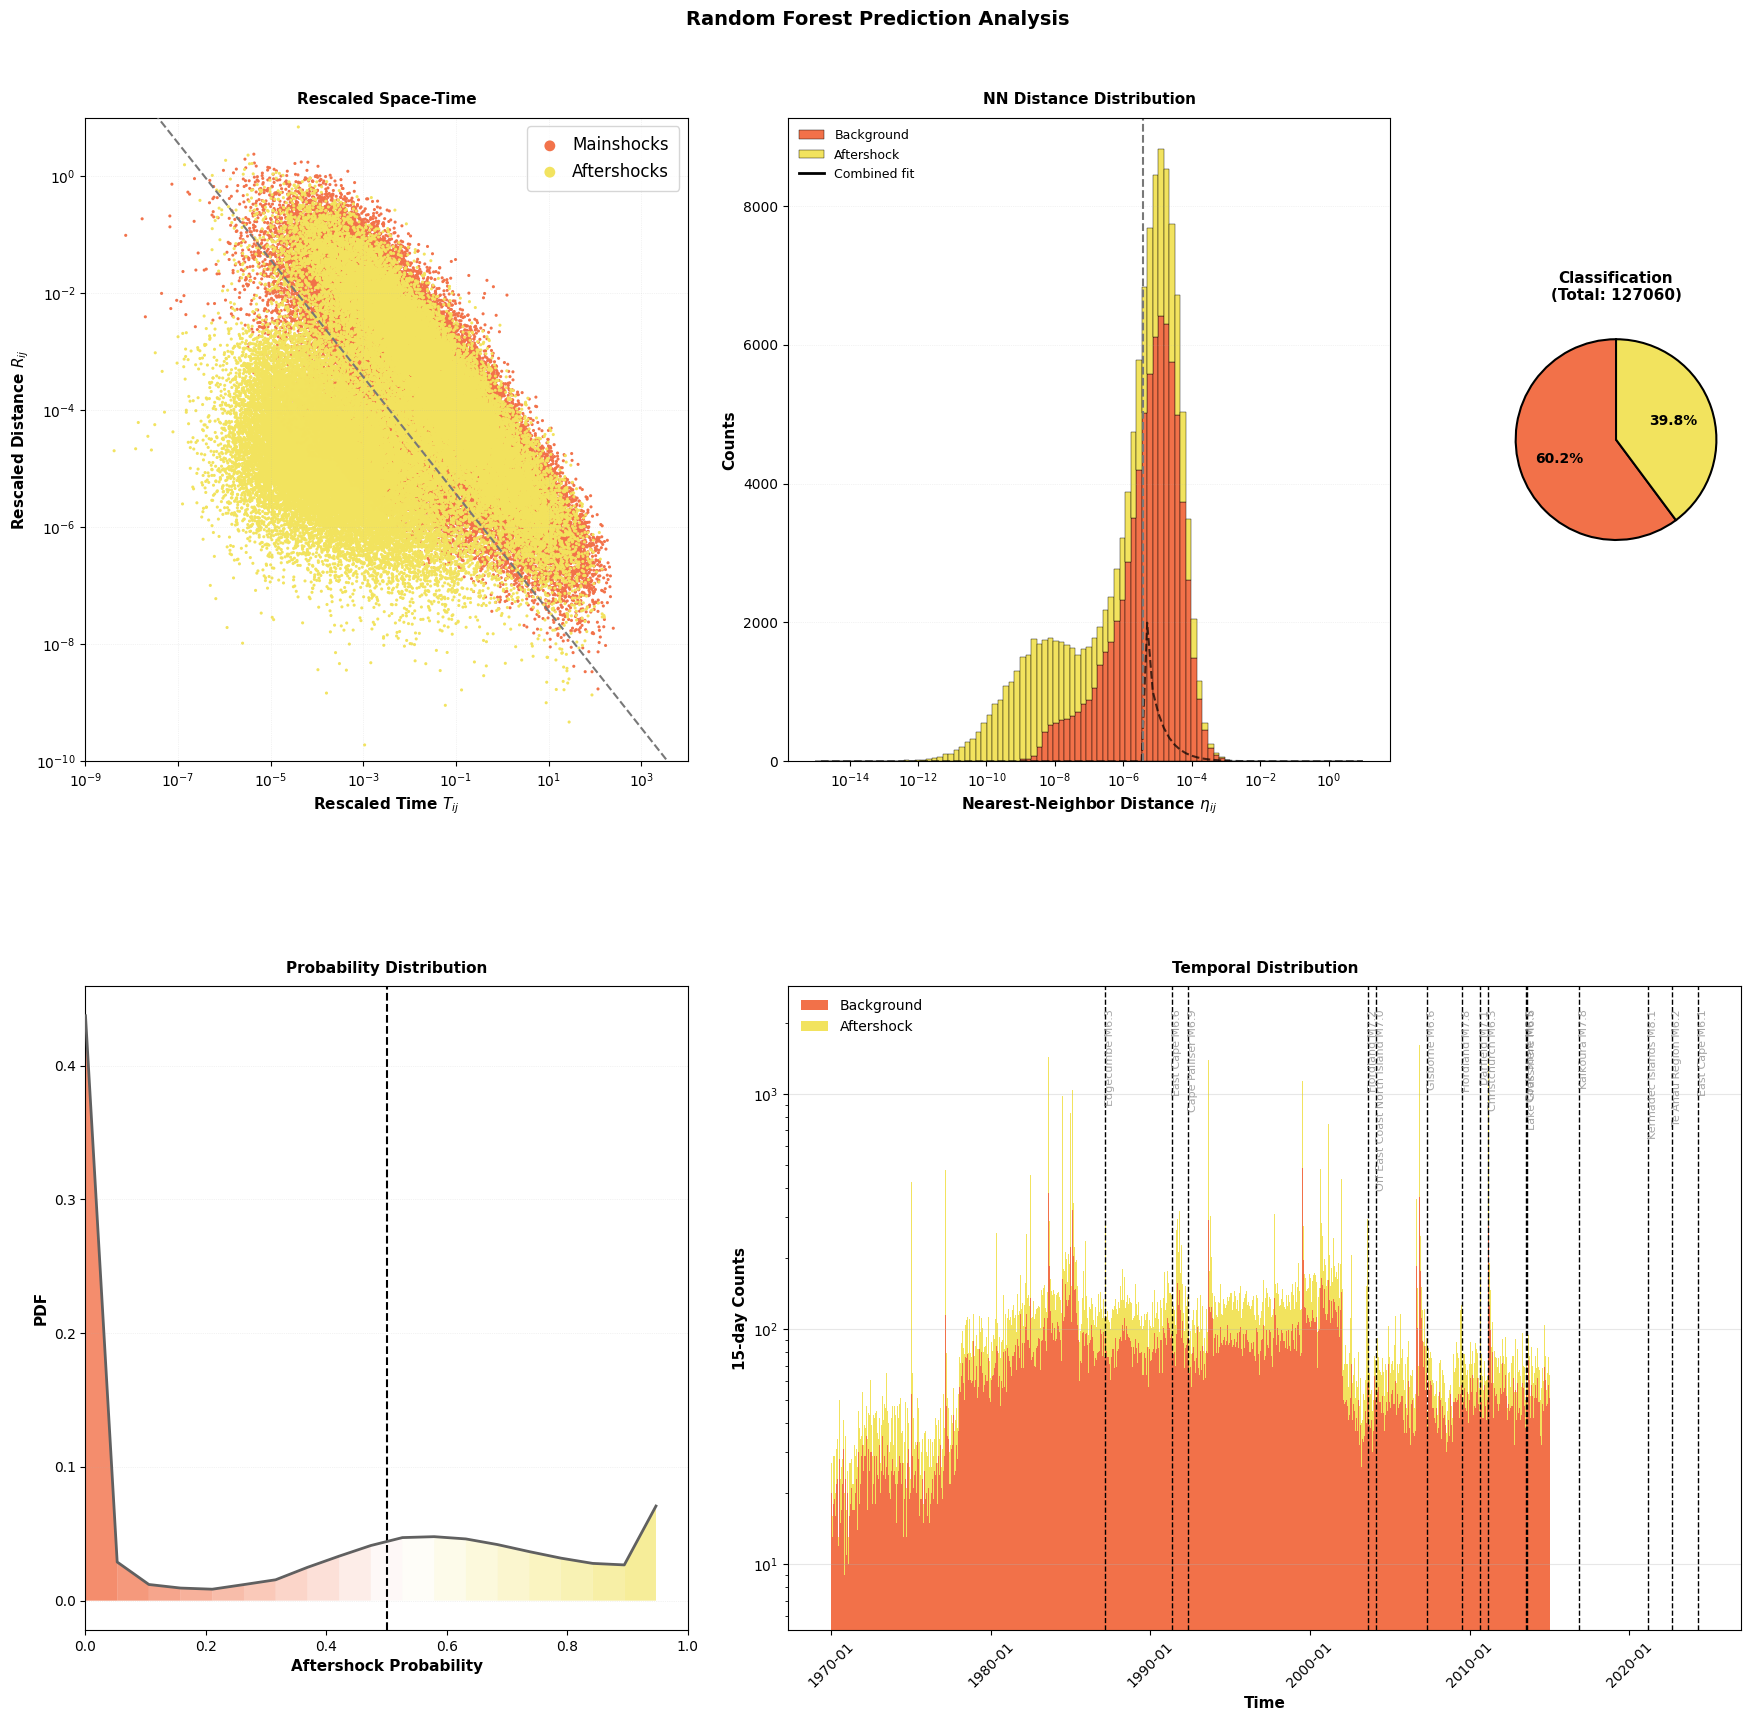

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mc
from scipy.optimize import minimize
from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings('ignore')

# -----------------------
# Configuration
# -----------------------
CONFIG = {
    'figure_size': (18, 18),  
    'dpi': 300,
    'colors': {
        'mainshock': '#f27149',
        'aftershock': '#f2e35e',
        'boundary': '#787878',
        'text': '#606060'
    },
    'scatter_size': 5,
    'weibull_bins': 100,
    'prob_bins': 20
}
# -----------------------
# Major historical earthquakes (New Zealand)
# -----------------------
MAJOR_EVENTS_NZ = {
    # 1980s
    '1987-03-02': 'Edgecumbe M6.3',

    # 1990s
    '1991-05-13': 'East Cape M6.6',
    '1992-05-19': 'Cape Palliser M6.9',

    # 2000s
    '2003-08-22': 'Fiordland M7.2',
    '2004-02-21': 'Off East Coast North Island M7.0',
    '2007-04-30': 'Gisborne M6.6',
    '2009-07-15': 'Fiordland M7.8',

    # 2010s — Canterbury sequence & Kaikōura
    '2010-09-04': 'Darfield M7.1',
    '2011-02-22': 'Christchurch M6.3',
    '2013-07-21': 'Cook Strait M6.5',
    '2013-08-16': 'Lake Grassmere M6.6',
    '2016-11-14': 'Kaikōura M7.8',

    # 2020s
    '2021-03-05': 'Kermadec Islands M8.1',
    '2022-09-10': 'Te Anau Region M6.2',
    '2024-04-30': 'East Cape M6.1'
}

# -----------------------
# Distribution fit functions
# -----------------------
def gaussian(x, a, x0, sigma):
    """Gaussian distribution."""
    return a * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

def weibull(x, x0, a, lambda_, k):
    """Weibull distribution with location parameter."""
    
    z = (x - x0) / lambda_
    y = (k / lambda_) * (z ** (k - 1)) * np.exp(-(z ** k))
    y[x < x0] = 0
    return a * y

def objfun_weibull(params, x, y):
    """Objective function for Weibull fitting (RMSE)."""
    x0, a, lambda_, k = params
    f_theo = weibull(x, x0, a, lambda_, k)
    return np.sqrt(np.mean((y - f_theo) ** 2))

# -----------------------
# Data Processing
# -----------------------
def load_and_validate_data(prediction_csv):
    """Load CSV and validate required columns."""
    print(f"📂 Loading: {prediction_csv}")
    df = pd.read_csv(prediction_csv)
    
    # Find probability column
    prob_col = next((c for c in df.columns if "Probability" in c and "triggered" in c), None)
    if prob_col is None:
        raise ValueError("❌ No aftershock probability column found.")
    
    if 'N+' not in df.columns:
        raise ValueError("❌ Column 'N+' not found!")
    
    return df, prob_col

def extract_populations(df, prob_col):
    """Extract mainshock and aftershock populations."""
    prob = df[prob_col].values
    pred = np.round(prob)
    
    main_N = df.loc[pred == 0, 'N+'][df.loc[pred == 0, 'N+'] > 0]
    after_N = df.loc[pred == 1, 'N+'][df.loc[pred == 1, 'N+'] > 0]
    
    print(f"📊 Background events: {len(main_N)} | Aftershock events: {len(after_N)}")
    
    return prob, pred, main_N, after_N

def fit_weibull_distributions(main_N, after_N, n_bins=100):
    """Fit Weibull distributions to populations."""
    bins = np.linspace(-15, 1, n_bins)
    
    # Main shock fit
    hb, _ = np.histogram(np.log10(main_N), bins)
    pm = minimize(objfun_weibull, x0=(-8, 500, 6, 8), args=(bins[:-1], hb))
    
    # Aftershock fit
    ha, _ = np.histogram(np.log10(after_N), bins)
    pa = minimize(objfun_weibull, x0=(-12, 500, 6, 8), args=(bins[:-1], ha))
    
    x = bins[0] + np.cumsum(np.diff(bins))
    fit_main = weibull(x, *pm.x)
    fit_after = weibull(x, *pa.x)
    
    return x, bins, hb, ha, fit_main, fit_after

# -----------------------
# Plotting Functions
# -----------------------

def plot_scatter(ax, df, pred, prob):
    """Plot scatter (T+ vs R+)."""
    colors = CONFIG['colors']
    
    if not {'T+', 'R+'}.issubset(df.columns):
        ax.text(0.5, 0.5, 'T+ or R+ not available', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        return
    
    cmap_main = mc.LinearSegmentedColormap.from_list(
        'main', [(0, (*mc.to_rgb(colors['mainshock']), 0)), (1, colors['mainshock'])]
    )
    cmap_after = mc.LinearSegmentedColormap.from_list(
        'after', [(0, (*mc.to_rgb(colors['aftershock']), 0)), (1, colors['aftershock'])]
    )
    
    ax.scatter(df.loc[pred == 0, 'T+'], df.loc[pred == 0, 'R+'],
               s=CONFIG['scatter_size'], c=1 - prob[pred == 0], 
               cmap=cmap_main, ec='None', alpha=.99, label='Mainshocks')
    ax.scatter(df.loc[pred == 1, 'T+'], df.loc[pred == 1, 'R+'],
               s=CONFIG['scatter_size'], c=prob[pred == 1], 
               cmap=cmap_after, ec='None', alpha=0.99, label='Aftershocks')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-9, 1e4)
    ax.set_ylim(1e-10, 10)
    ax.set_xlabel(r'Rescaled Time $T_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel(r'Rescaled Distance $R_{ij}$', fontsize=11, fontweight='bold')
    #ax.legend(frameon=False, loc='upper right', fontsize=9)
    ax.legend(
     frameon=True,
     loc='upper right',
     fontsize=12,           # ← Increased font size
     markerscale=3.5,       # ← Enlarge legend marker size
     handlelength=1.5,
     handletextpad=0.6,
     borderpad=0.6
    )

    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_title('Rescaled Space-Time', fontsize=11, fontweight='bold', pad=10)
    
    # Separation boundary
    threshold = 3.7e-7
    tij = np.array([1e-9, 1e4], dtype=float)
    rij = threshold / tij
    ax.plot(tij, rij, '--', c=colors['boundary'], linewidth=1.5, 
            label='Threshold', zorder=10)
#--------------------------------------------------------------------------------

#                   HISTOGRAM OF N+

#--------------------------------------------------------------------------------
def plot_histogram(ax, df, pred, x, fit_main, fit_after):
    """Plot histogram of N+."""
    colors = CONFIG['colors']
    
    ax.hist([df.loc[pred == 0, 'N+'], df.loc[pred == 1, 'N+']],
            bins=10 ** np.linspace(-15, 1, 100),
            stacked=True, color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'], edgecolor='black', linewidth=0.3)
    
    ax.semilogx(10 ** x, fit_main, 'k--', linewidth=1.5, alpha=0.7)
    ax.semilogx(10 ** x, fit_after, 'k--', linewidth=1.5, alpha=0.7)
    ax.semilogx(10 ** x, fit_after + fit_main, 'k-', linewidth=2, label='Combined fit')
    ax.axvline(3.7e-6, ls='--', c=colors['boundary'], linewidth=1.5)
    
    ax.set_xlabel(r'Nearest-Neighbor Distance $\eta_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel('Counts', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y', linestyle=':', linewidth=0.5)
    ax.set_title('NN Distance Distribution', fontsize=11, fontweight='bold', pad=10)
#--------------------------------------------------------------------------------

#                   PROBABILITY DISTRIBUTION

#-------------------------  ----------------------------------------------------
def plot_probability_distribution(ax, prob):
    """Plot probability distribution."""
    colors = CONFIG['colors']
    
    h, bins_prob = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    h = h / h.sum()
    bins_prob = bins_prob[:-1]
    
    ax.plot(bins_prob, h, c=colors['text'], linewidth=2, zorder=10)
    
    for i in range(len(bins_prob) - 1):
        b = bins_prob[i:i + 2]
        h_ = h[i:i + 2]
        if b[0] <= 0.5:
            color = colors['mainshock']
            alpha = 1 - b[0] / 0.5
        else:
            color = colors['aftershock']
            alpha = (b[0] - 0.5) / 0.5
        ax.fill_between(b, h_, fc=color, ec='None', alpha=alpha * 0.8)
    
    ax.axvline(0.5, linestyle='--', color='k', linewidth=1.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', linestyle=':', linewidth=0.5)
    ax.set_title('Probability Distribution', fontsize=11, fontweight='bold', pad=10)
#--------------------------------------------------------------------------------

#                   TEMPORAL HISTOGRAM

#-------------------------  ----------------------------------------------------
def plot_temporal_histogram(ax, df, pred, dt=15):
    """Plot temporal distribution."""
    if 'time' not in df.columns:
        ax.text(0.5, 0.5, 'Time column not available', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.axis('off')
        return
    
    colors = CONFIG['colors']
    bins_time = np.arange(int(df['time'].min()), int(df['time'].max()) + dt, dt)
    
    ax.hist([df.loc[pred == 0, 'time'], df.loc[pred == 1, 'time']],
            bins=bins_time, stacked=True, 
            color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'])
    
    ax.set_yscale('log')
    ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    # ax.xaxis.set_major_formatter(md.DateFormatter('%Y'))
    # plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    # ax.legend(frameon=False, loc='upper left', fontsize=9)
    # ax.grid(True, alpha=0.3, axis='y', linestyle=':', linewidth=0.5)
    ax.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(frameon=False, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title('Temporal Distribution', fontsize=11, fontweight='bold', pad=10)
    """
    Major earthquake annotations

    """
    for date_str, label in MAJOR_EVENTS_NZ.items():
        date = pd.to_datetime(date_str)
        ax.axvline(date, color='black', linestyle='--', linewidth=1)
        ax.text(date, ax.get_ylim()[1]*0.8, label, rotation=90, verticalalignment='top',
                fontsize=8, color='gray', alpha=0.7)
        
"""
    ax4.set_yscale('log')
    ax4.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Time', fontsize=11, fontweight='bold')
    ax4.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
    ax4.legend(frameon=False, loc='upper left')
    ax4.grid(True, alpha=0.3, axis='y')
"""
    

#--------------------------------------------------------------------------------

#                   PIE CHART

#-------------------------  ----------------------------------------------------
def plot_pie_chart(ax, pred):
    """Add pie chart with counts."""
    colors = CONFIG['colors']
    n_bg, n_af = (pred == 0).sum(), (pred == 1).sum()
    
    wedges, texts, autotexts = ax.pie(
        [n_bg, n_af], 
        colors=[colors['mainshock'], colors['aftershock']],
        autopct='%1.1f%%',
        wedgeprops={"edgecolor": "k", 'linewidth': 1.5},
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        startangle=90
    )
    
    ax.set_title(f'Classification\n(Total: {n_bg + n_af})', 
                fontsize=11, fontweight='bold', pad=10)

# -----------------------
# Main plotting function (LANDSCAPE LAYOUT)
# -----------------------
def plot_from_prediction_csv(prediction_csv, figure_name='RF_predictions_landscape.png', dt=15, save=True):
    """Generate comprehensive visualization from prediction CSV in landscape mode."""
    
    # Load and validate
    df, prob_col = load_and_validate_data(prediction_csv)
    prob, pred, main_N, after_N = extract_populations(df, prob_col)
    
    # Fit distributions
    x, bins, hb, ha, fit_main, fit_after = fit_weibull_distributions(main_N, after_N)
    
    # Create figure with landscape layout (2 rows × 3 columns)
    fig = plt.figure(figsize=CONFIG['figure_size'], dpi=100)
    gs = fig.add_gridspec(2, 5, hspace=0.35, wspace=0.4, 
                         left=0.06, right=0.98, top=0.92, bottom=0.08)
    
    # Top row: Scatter, Histogram, Pie
    ax1 = fig.add_subplot(gs[0, 0:2])   # Scatter (spans 2 cols)
    ax2 = fig.add_subplot(gs[0, 2:4])   # Histogram (spans 2 cols)
    ax_pie = fig.add_subplot(gs[0, 4])  # Pie chart
    
    # Bottom row: Probability and Temporal
    ax3 = fig.add_subplot(gs[1, 0:2])   # Probability (spans 2 cols)
    ax4 = fig.add_subplot(gs[1, 2:])    # Temporal (spans 3 cols)
    
    # Plot components
    plot_scatter(ax1, df, pred, prob)
    plot_histogram(ax2, df, pred, x, fit_main, fit_after)
    plot_pie_chart(ax_pie, pred)
    plot_probability_distribution(ax3, prob)
    plot_temporal_histogram(ax4, df, pred, dt)
    
    # Add overall title
    fig.suptitle('Random Forest Prediction Analysis', 
                fontsize=14, fontweight='bold')
    
    if save:
        plt.savefig(figure_name, dpi=CONFIG['dpi'], bbox_inches='tight')
        print(f"✅ Plot saved as {figure_name}")
    
    plt.show()
    
    return fig, (ax1, ax2, ax3, ax4, ax_pie)

# -----------------------
# Run Example
# -----------------------
if __name__ == "__main__":
    csv_path = "/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251108_190748/new_data_predictions.csv"
    plot_from_prediction_csv(csv_path, save=True)

In [28]:
prediction_data=pd.read_csv("/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251108_190748/new_data_predictions.csv")
prediction_data.head()

,event,time,latitude,longitude,magnitude,i+,N+,T+,R+,dm+,n_child,n_parent,Predicted_Label,Predicted_Label_Name,Probability_background,Probability_triggered
0,3,0.475062,-37.63,176.38000,4.150,0,0.001304,0.008451,0.154341,-0.950,0.517447,0.129362,1,triggered,0.462016,0.537984
1,4,0.553338,-40.29,173.42999,4.500,1,0.000038,0.000571,0.066251,-0.350,0.258723,0.517447,0,background,0.576840,0.423160
2,5,1.472336,-38.48,176.75000,3.375,1,0.000047,0.007270,0.006458,0.775,0.000000,0.517447,0,background,0.988779,0.011221
3,7,2.766910,-36.66,177.45000,4.818,1,0.000219,0.016708,0.013127,-0.668,1.552340,0.517447,0,background,0.636720,0.363280
4,8,2.809132,-38.71,175.94000,4.011,4,0.000002,0.000139,0.014728,0.807,0.258723,1.552340,1,triggered,0.449338,0.550662


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mc
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings('ignore')

# -----------------------
# Configuration
# -----------------------
CONFIG = {
    'figure_size': (18, 10),  
    'dpi': 300,
    'colors': {
        'mainshock': '#f27149',
        'aftershock': '#f2e35e',
        'boundary': '#787878',
        'text': '#606060'
    },
    'scatter_size': 5,
    'weibull_bins': 100,
    'prob_bins': 20
}

# -----------------------
# Major historical earthquakes (New Zealand)
# -----------------------
MAJOR_EVENTS_NZ = {
    '1987-03-02': 'Edgecumbe M6.3',
    '1991-05-13': 'East Cape M6.6',
    '1992-05-19': 'Cape Palliser M6.9',
    '2003-08-22': 'Fiordland M7.2',
    '2004-02-21': 'Off East Coast North Island M7.0',
    '2007-04-30': 'Gisborne M6.6',
    '2009-07-15': 'Fiordland M7.8',
    '2010-09-04': 'Darfield M7.1',
    '2011-02-22': 'Christchurch M6.3',
    '2013-07-21': 'Cook Strait M6.5',
    '2013-08-16': 'Lake Grassmere M6.6',
    '2016-11-14': 'Kaikōura M7.8',
    '2021-03-05': 'Kermadec Islands M8.1',
    '2022-09-10': 'Te Anau Region M6.2',
    '2024-04-30': 'East Cape M6.1'
}

# -----------------------
# Data Processing
# -----------------------
def load_and_validate_data(prediction_csv):
    """Load CSV and validate required columns."""
    print(f"📂 Loading: {prediction_csv}")
    df = pd.read_csv(prediction_csv)
    
    prob_col = next((c for c in df.columns if "Probability" in c and "triggered" in c), None)
    if prob_col is None:
        raise ValueError("❌ No aftershock probability column found.")
    
    if 'N+' not in df.columns:
        raise ValueError("❌ Column 'N+' not found!")
    
    return df, prob_col

def extract_populations(df, prob_col):
    """Extract mainshock and aftershock populations."""
    prob = df[prob_col].values
    pred = np.round(prob)
    
    main_N = df.loc[pred == 0, 'N+'][df.loc[pred == 0, 'N+'] > 0]
    after_N = df.loc[pred == 1, 'N+'][df.loc[pred == 1, 'N+'] > 0]
    
    print(f"📊 Background events: {len(main_N)} | Aftershock events: {len(after_N)}")
    return prob, pred, main_N, after_N

# -----------------------
# Plotting Functions
# -----------------------

def plot_scatter(ax, df, pred, prob):
    """Plot scatter (T+ vs R+)."""
    colors = CONFIG['colors']
    
    if not {'T+', 'R+'}.issubset(df.columns):
        ax.text(0.5, 0.5, 'T+ or R+ not available', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        return
    
    cmap_main = mc.LinearSegmentedColormap.from_list(
        'main', [(0, (*mc.to_rgb(colors['mainshock']), 0)), (1, colors['mainshock'])]
    )
    cmap_after = mc.LinearSegmentedColormap.from_list(
        'after', [(0, (*mc.to_rgb(colors['aftershock']), 0)), (1, colors['aftershock'])]
    )
    
    ax.scatter(df.loc[pred == 0, 'T+'], df.loc[pred == 0, 'R+'],
               s=CONFIG['scatter_size'], c=1 - prob[pred == 0], 
               cmap=cmap_main, ec='None', alpha=.99, label='Mainshocks')
    ax.scatter(df.loc[pred == 1, 'T+'], df.loc[pred == 1, 'R+'],
               s=CONFIG['scatter_size'], c=prob[pred == 1], 
               cmap=cmap_after, ec='None', alpha=0.99, label='Aftershocks')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-9, 1e4)
    ax.set_ylim(1e-10, 10)
    ax.set_xlabel(r'Rescaled Time $T_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel(r'Rescaled Distance $R_{ij}$', fontsize=11, fontweight='bold')
    ax.legend(frameon=True, loc='upper right', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_title('Rescaled Space-Time', fontsize=11, fontweight='bold', pad=10)
    
    # Separation boundary
    threshold = 3.54e-7
    tij = np.array([1e-9, 1e4], dtype=float)
    rij = threshold / tij
    ax.plot(tij, rij, '--', c=colors['boundary'], linewidth=1.5, zorder=10)

# -----------------------
# HISTOGRAM OF N+ WITH GMM
# -----------------------
def plot_histogram(ax, df, pred):
    """Plot histogram of N+ using Gaussian Mixture Model."""
    colors = CONFIG['colors']
    
    # --- Prepare log data ---
    valid = df['N+'] > 0
    log_eta = np.log10(df.loc[valid, 'N+'].values).reshape(-1, 1)
    
    # --- Fit 2-component GMM ---
    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(log_eta)
    
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()
    weights = gmm.weights_.flatten()
    order = np.argsort(means)
    mu1, mu2 = means[order]
    sigma1, sigma2 = stds[order]
    w1, w2 = weights[order]

    x = np.linspace(log_eta.min(), log_eta.max(), 2000)
    pdf1 = w1 * norm.pdf(x, mu1, sigma1)
    pdf2 = w2 * norm.pdf(x, mu2, sigma2)
    mixture = pdf1 + pdf2

    # --- Intersection threshold ---
    threshold_idx = np.argwhere(np.diff(np.sign(pdf1 - pdf2))).flatten()
    threshold = x[threshold_idx][0] if len(threshold_idx) > 0 else None

    # --- Plot histogram for both background/aftershock ---
    ax.hist([df.loc[pred == 0, 'N+'], df.loc[pred == 1, 'N+']],
            bins=10 ** np.linspace(-15, 1, 100),
            stacked=True, color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'], edgecolor='black', linewidth=0.3, alpha=0.8)

    # --- Overlay GMM fits ---
    # --- Clip the PDF domain to the observed η range ---
    x_eta = 10 ** x
    mask = (x_eta >= df['N+'].min()) & (x_eta <= df['N+'].max())
    ax2 = ax.twinx()
    ax2.plot(x_eta[mask], pdf1[mask], 'r--', lw=1.5, label='Gaussian 1')
    ax2.plot(x_eta[mask], pdf2[mask], 'b--', lw=1.5, label='Gaussian 2')
    ax2.plot(x_eta[mask], mixture[mask], 'k-', lw=2, label='Mixture')
    
    # ax2 = ax.twinx()
    # ax2.plot(10 ** x, pdf1, 'r--', lw=1.5, label='Gaussian 1')
    # ax2.plot(10 ** x, pdf2, 'b--', lw=1.5, label='Gaussian 2')
    # ax2.plot(10 ** x, mixture, 'k-', lw=2, label='Mixture')

    if threshold is not None:
        ax.axvline(10 ** threshold, ls='--', c='m', lw=2,
                   label=f'Threshold = {10 ** threshold:.2e}')

    # --- Styling -
    ax.set_xscale('log')
    ax.set_xlabel(r'Nearest-Neighbor Distance $\eta_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel('Counts', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Density (GMM)')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax2.legend(frameon=False, fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    ax.set_title('NN Distance Distribution (GMM)', fontsize=11, fontweight='bold', pad=10)
    
    print(f"📈 GMM Params: μ1={mu1:.2f}, μ2={mu2:.2f}, σ1={sigma1:.2f}, σ2={sigma2:.2f}, threshold={10**threshold:.2e}")

# -----------------------
# Other Plots (Probability, Temporal, Pie)
# -----------------------
# def plot_probability_distribution(ax, prob):
    # colors = CONFIG['colors']
    # h, bins_prob = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    # h = h / h.sum()
    # bins_prob = bins_prob[:-1]
    # 
    # ax.plot(bins_prob, h, c=colors['text'], linewidth=2)
    # for i in range(len(bins_prob) - 1):
        # b = bins_prob[i:i + 2]; h_ = h[i:i + 2]
        # color = colors['mainshock'] if b[0] <= 0.5 else colors['aftershock']
        # alpha = 1 - abs(b[0] - 0.5) * 2
        # ax.fill_between(b, h_, fc=color, alpha=alpha * 1.0)
    # ax.axvline(0.5, linestyle='--', color='k', linewidth=1.0)
    # ax.set_xlim(0, 1)
    # ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    # ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    # ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    # ax.set_title('Probability Distribution', fontsize=11, fontweight='bold')
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def plot_probability_distribution(ax, prob):
    """Smooth probability distribution with fading orange→yellow transition."""
    
    # Define key colors
    color_main = '#ff7f0e'   # orange (mainshock side)
    color_after = '#fff700'  # bright yellow (aftershock side)
    boundary_color = '#111111'

    # Compute normalized histogram
    h, bins = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    h = h / h.sum()
    centers = (bins[:-1] + bins[1:]) / 2

    # Smooth curve for better appearance
    smooth_x = np.linspace(0, 1, 300)
    spline = make_interp_spline(centers, h, k=3)
    smooth_y = spline(smooth_x)

    # Create base gradient colormap (orange → yellow)
    cmap = mcolors.LinearSegmentedColormap.from_list("orange_yellow", [color_main, color_after])

    # Fill region with fading color based on probability
    for i in range(len(smooth_x) - 1):
        x0, x1 = smooth_x[i], smooth_x[i + 1]
        y0, y1 = smooth_y[i], smooth_y[i + 1]

        # Compute color transition factor
        if x0 < 0.5:
            # Left side: orange fades out
            fade = 1 - (x0 / 0.5) ** 1.2     # nonlinear smooth fade
            color = mcolors.to_rgba(color_main, alpha=fade)
        else:
            # Right side: yellow fades in
            grow = ((x0 - 0.5) / 0.5) ** 1.2
            color = mcolors.to_rgba(color_after, alpha=grow)

        ax.fill_between([x0, x1], [y0, y1], color=color, linewidth=0)

    # Draw boundary curve
    ax.plot(smooth_x, smooth_y, color=boundary_color, lw=1.8, zorder=5)

    # Add vertical threshold line
    ax.axvline(0.5, linestyle='--', color='k', lw=1.2)

    # Styling
    ax.set_xlim(0, 1)
    ax.set_ylim(0, smooth_y.max() * 1.15)
    ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    ax.set_title('Probability Distribution', fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, axis='y', alpha=0.25, linestyle=':')

    # Region labels
    ax.text(0.1, smooth_y.max() * 0.85, 'Mainshock', color=color_main,
            fontsize=10, weight='bold', ha='left')
    ax.text(0.75, smooth_y.max() * 0.85, 'Aftershock', color="yellow",
            fontsize=10, weight='bold', ha='right')

def plot_temporal_histogram(ax, df, pred, dt=15):
    if 'time' not in df.columns:
        ax.text(0.5, 0.5, 'Time column not available', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
        return
    colors = CONFIG['colors']
    bins_time = np.arange(int(df['time'].min()), int(df['time'].max()) + dt, dt)
    ax.hist([df.loc[pred == 0, 'time'], df.loc[pred == 1, 'time']],
            bins=bins_time, stacked=True, color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'])
    ax.set_yscale('log')
    ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(frameon=False, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title('Temporal Distribution', fontsize=11, fontweight='bold', pad=10)

def plot_pie_chart(ax, pred):
    colors = CONFIG['colors']
    n_bg, n_af = (pred == 0).sum(), (pred == 1).sum()
    ax.pie([n_bg, n_af], colors=[colors['mainshock'], colors['aftershock']],
           autopct='%1.1f%%', startangle=90, wedgeprops={"edgecolor": "k", 'linewidth': 1.5})
    ax.set_title(f'Classification\n(Total: {n_bg + n_af})', fontsize=11, fontweight='bold', pad=10)

# -----------------------
# Main Function
# -----------------------
def plot_from_prediction_csv(prediction_csv, figure_name='gmm_RF_predictions_landscape.png', dt=15, save=True):
    df, prob_col = load_and_validate_data(prediction_csv)
    prob, pred, main_N, after_N = extract_populations(df, prob_col)
    
    fig = plt.figure(figsize=CONFIG['figure_size'], dpi=100)
    gs = fig.add_gridspec(2, 5, hspace=0.35, wspace=0.4, left=0.06, right=0.98, top=0.92, bottom=0.08)
    
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax_pie = fig.add_subplot(gs[0, 4])
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax4 = fig.add_subplot(gs[1, 2:])
    
    plot_scatter(ax1, df, pred, prob)
    plot_histogram(ax2, df, pred)
    plot_pie_chart(ax_pie, pred)
    plot_probability_distribution(ax3, prob)
    plot_temporal_histogram(ax4, df, pred, dt)
    
    fig.suptitle('Random Forest Prediction Analysis', fontsize=14, fontweight='bold')
    
    if save:
        plt.savefig(figure_name, dpi=CONFIG['dpi'], bbox_inches='tight')
        print(f"✅ Plot saved as {figure_name}")
    plt.show()

# -----------------------
# Run Example
# -----------------------
if __name__ == "__main__":
    csv_path = "/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251108_190748/new_data_predictions.csv"
    plot_from_prediction_csv(csv_path, save=True)
    """Generate comprehensive visualization from prediction CSV."""
    

# Entire data from 1980-2024

In [27]:
new_df=pd.read_csv( "/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251109_215442/Entire_nz_prediction_rf.csv")
new_df.head()

,event,date,Time,latitude,longitude,depth,magnitude,DateTime,time,Year,...,N+,T+,R+,dm+,n_child,n_parent,Predicted_Label,Predicted_Label_Name,Probability_background,Probability_triggered
0,2,1980-01-01,09:27:04.52,-40.490,174.66901,72.6,3.200,1980-01-01 09:27:04.520,0.099293,1980,...,0.000217,0.004731,0.045941,-0.633,0.082958,0.041479,1,triggered,0.393115,0.606885
1,3,1980-01-01,18:28:10.99,-37.630,176.38000,210.0,4.150,1980-01-01 18:28:10.990,0.475062,1980,...,0.001304,0.008451,0.154341,-0.950,0.124437,0.082958,0,background,0.603004,0.396996
2,4,1980-01-01,20:20:54.03,-40.290,173.42999,212.0,4.500,1980-01-01 20:20:54.030,0.553338,1980,...,0.000038,0.000571,0.066251,-0.350,0.165915,0.124437,0,background,0.594656,0.405344
3,5,1980-01-02,18:24:15.40,-38.480,176.75000,5.0,3.375,1980-01-02 18:24:15.400,1.472336,1980,...,0.000047,0.007270,0.006458,0.775,0.000000,0.124437,0,background,0.991059,0.008941
4,6,1980-01-04,01:21:41.06,-40.906,175.23700,24.1,2.750,1980-01-04 01:21:41.060,2.762216,1980,...,0.000144,0.010633,0.013547,1.750,0.041479,0.165915,1,triggered,0.387073,0.612927


📂 Loading: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251109_215442/Entire_nz_prediction_rf.csv
📊 Background events: 272671 | Aftershock events: 116339
📈 GMM Params: μ1=-7.59, μ2=-4.96, σ1=1.26, σ2=0.61, threshold=5.99e-07
✅ Plot saved as ENTIRE_NZ_gmm_RF_predictions_landscape.png


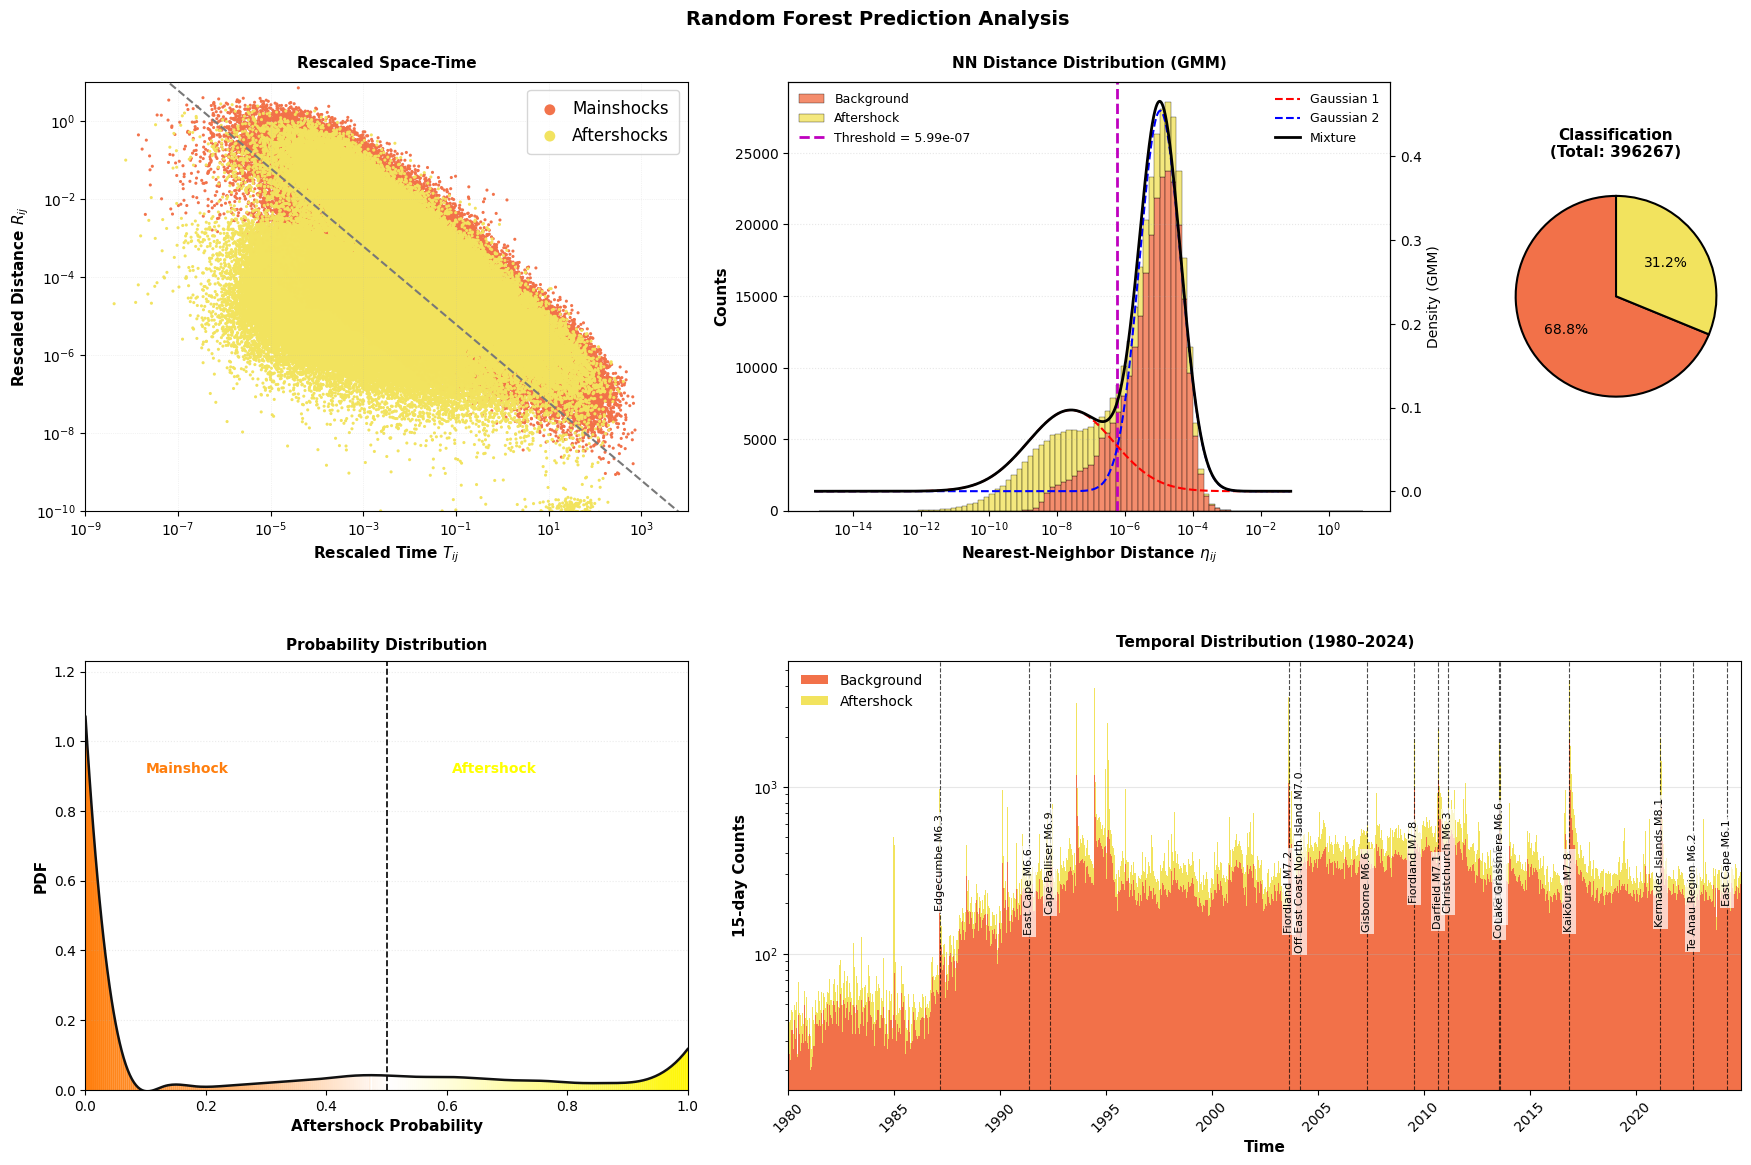

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mc
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings('ignore')

# -----------------------
# Configuration
# -----------------------
CONFIG = {
    'figure_size': (18, 12),  
    'dpi': 300,
    'colors': {
        'mainshock': '#f27149',
        'aftershock': '#f2e35e',
        'boundary': '#787878',
        'text': '#606060'
    },
    'scatter_size': 5,
    'weibull_bins': 100,
    'prob_bins': 20
}

# -----------------------
# Major historical earthquakes (New Zealand)
# -----------------------
MAJOR_EVENTS_NZ = {
    '1987-03-02': 'Edgecumbe M6.3',
    '1991-05-13': 'East Cape M6.6',
    '1992-05-19': 'Cape Palliser M6.9',
    '2003-08-22': 'Fiordland M7.2',
    '2004-02-21': 'Off East Coast North Island M7.0',
    '2007-04-30': 'Gisborne M6.6',
    '2009-07-15': 'Fiordland M7.8',
    '2010-09-04': 'Darfield M7.1',
    '2011-02-22': 'Christchurch M6.3',
    '2013-07-21': 'Cook Strait M6.5',
    '2013-08-16': 'Lake Grassmere M6.6',
    '2016-11-14': 'Kaikōura M7.8',
    '2021-03-05': 'Kermadec Islands M8.1',
    '2022-09-10': 'Te Anau Region M6.2',
    '2024-04-30': 'East Cape M6.1'
}

# -----------------------
# Data Processing
# -----------------------
def load_and_validate_data(prediction_csv):
    """Load CSV and validate required columns."""
    print(f"📂 Loading: {prediction_csv}")
    df = pd.read_csv(prediction_csv)
    
    prob_col = next((c for c in df.columns if "Probability" in c and "triggered" in c), None)
    if prob_col is None:
        raise ValueError("❌ No aftershock probability column found.")
    
    if 'N+' not in df.columns:
        raise ValueError("❌ Column 'N+' not found!")
    
    return df, prob_col

def extract_populations(df, prob_col):
    """Extract mainshock and aftershock populations."""
    prob = df[prob_col].values
    pred = np.round(prob)
    
    main_N = df.loc[pred == 0, 'N+'][df.loc[pred == 0, 'N+'] > 0]
    after_N = df.loc[pred == 1, 'N+'][df.loc[pred == 1, 'N+'] > 0]
    
    print(f"📊 Background events: {len(main_N)} | Aftershock events: {len(after_N)}")
    return prob, pred, main_N, after_N

# -----------------------
# Plotting Functions
# -----------------------

def plot_scatter(ax, df, pred, prob):
    """Plot scatter (T+ vs R+)."""
    colors = CONFIG['colors']
    
    if not {'T+', 'R+'}.issubset(df.columns):
        ax.text(0.5, 0.5, 'T+ or R+ not available', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        return
    
    cmap_main = mc.LinearSegmentedColormap.from_list(
        'main', [(0, (*mc.to_rgb(colors['mainshock']), 0)), (1, colors['mainshock'])]
    )
    cmap_after = mc.LinearSegmentedColormap.from_list(
        'after', [(0, (*mc.to_rgb(colors['aftershock']), 0)), (1, colors['aftershock'])]
    )
    
    ax.scatter(df.loc[pred == 0, 'T+'], df.loc[pred == 0, 'R+'],
               s=CONFIG['scatter_size'], c=1 - prob[pred == 0], 
               cmap=cmap_main, ec='None', alpha=.99, label='Mainshocks')
    ax.scatter(df.loc[pred == 1, 'T+'], df.loc[pred == 1, 'R+'],
               s=CONFIG['scatter_size'], c=prob[pred == 1], 
               cmap=cmap_after, ec='None', alpha=0.99, label='Aftershocks')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-9, 1e4)
    ax.set_ylim(1e-10, 10)
    ax.set_xlabel(r'Rescaled Time $T_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel(r'Rescaled Distance $R_{ij}$', fontsize=11, fontweight='bold')
    #ax.legend(frameon=True, loc='upper right', fontsize=12)
    ax.legend(
     frameon=True,
     loc='upper right',
     fontsize=12,           # ← Increased font size
     markerscale=3.5,       # ← Enlarge legend marker size
     handlelength=1.5,
     handletextpad=0.6,
     borderpad=0.6
    )
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_title('Rescaled Space-Time', fontsize=11, fontweight='bold', pad=10)
    
    # Separation boundary
    threshold = 5.99e-07
    tij = np.array([1e-9, 1e4], dtype=float)
    rij = threshold / tij
    ax.plot(tij, rij, '--', c=colors['boundary'], linewidth=1.5, zorder=10)

# -----------------------
# HISTOGRAM OF N+ WITH GMM
# -----------------------
def plot_histogram(ax, df, pred):
    """Plot histogram of N+ using Gaussian Mixture Model."""
    colors = CONFIG['colors']
    
    # --- Prepare log data ---
    valid = df['N+'] > 0
    log_eta = np.log10(df.loc[valid, 'N+'].values).reshape(-1, 1)
    
    # --- Fit 2-component GMM ---
    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(log_eta)
    
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()
    weights = gmm.weights_.flatten()
    order = np.argsort(means)
    mu1, mu2 = means[order]
    sigma1, sigma2 = stds[order]
    w1, w2 = weights[order]

    x = np.linspace(log_eta.min(), log_eta.max(), 2000)
    pdf1 = w1 * norm.pdf(x, mu1, sigma1)
    pdf2 = w2 * norm.pdf(x, mu2, sigma2)
    mixture = pdf1 + pdf2

    # --- Intersection threshold ---
    threshold_idx = np.argwhere(np.diff(np.sign(pdf1 - pdf2))).flatten()
    threshold = x[threshold_idx][0] if len(threshold_idx) > 0 else None

    # --- Plot histogram for both background/aftershock ---
    ax.hist([df.loc[pred == 0, 'N+'], df.loc[pred == 1, 'N+']],
            bins=10 ** np.linspace(-15, 1, 100),
            stacked=True, color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'], edgecolor='black', linewidth=0.3, alpha=0.8)

    # --- Overlay GMM fits ---
    # --- Clip the PDF domain to the observed η range ---
    x_eta = 10 ** x
    mask = (x_eta >= df['N+'].min()) & (x_eta <= df['N+'].max())
    ax2 = ax.twinx()
    ax2.plot(x_eta[mask], pdf1[mask], 'r--', lw=1.5, label='Gaussian 1')
    ax2.plot(x_eta[mask], pdf2[mask], 'b--', lw=1.5, label='Gaussian 2')
    ax2.plot(x_eta[mask], mixture[mask], 'k-', lw=2, label='Mixture')
    
    # ax2 = ax.twinx()
    # ax2.plot(10 ** x, pdf1, 'r--', lw=1.5, label='Gaussian 1')
    # ax2.plot(10 ** x, pdf2, 'b--', lw=1.5, label='Gaussian 2')
    # ax2.plot(10 ** x, mixture, 'k-', lw=2, label='Mixture')

    if threshold is not None:
        ax.axvline(10 ** threshold, ls='--', c='m', lw=2,
                   label=f'Threshold = {10 ** threshold:.2e}')

    # --- Styling -
    ax.set_xscale('log')
    ax.set_xlabel(r'Nearest-Neighbor Distance $\eta_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel('Counts', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Density (GMM)')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax2.legend(frameon=False, fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    ax.set_title('NN Distance Distribution (GMM)', fontsize=11, fontweight='bold', pad=10)
    
    print(f"📈 GMM Params: μ1={mu1:.2f}, μ2={mu2:.2f}, σ1={sigma1:.2f}, σ2={sigma2:.2f}, threshold={10**threshold:.2e}")

# -----------------------
# Other Plots (Probability, Temporal, Pie)
# -----------------------
# def plot_probability_distribution(ax, prob):
    # colors = CONFIG['colors']
    # h, bins_prob = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    # h = h / h.sum()
    # bins_prob = bins_prob[:-1]
    # 
    # ax.plot(bins_prob, h, c=colors['text'], linewidth=2)
    # for i in range(len(bins_prob) - 1):
        # b = bins_prob[i:i + 2]; h_ = h[i:i + 2]
        # color = colors['mainshock'] if b[0] <= 0.5 else colors['aftershock']
        # alpha = 1 - abs(b[0] - 0.5) * 2
        # ax.fill_between(b, h_, fc=color, alpha=alpha * 1.0)
    # ax.axvline(0.5, linestyle='--', color='k', linewidth=1.0)
    # ax.set_xlim(0, 1)
    # ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    # ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    # ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    # ax.set_title('Probability Distribution', fontsize=11, fontweight='bold')
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def plot_probability_distribution(ax, prob):
    """Smooth probability distribution with fading orange→yellow transition."""
    
    # Define key colors
    color_main = '#ff7f0e'   # orange (mainshock side)
    color_after = '#fff700'  # bright yellow (aftershock side)
    boundary_color = '#111111'

    # Compute normalized histogram
    h, bins = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    h = h / h.sum()
    centers = (bins[:-1] + bins[1:]) / 2

    # Smooth curve for better appearance
    smooth_x = np.linspace(0, 1, 300)
    spline = make_interp_spline(centers, h, k=3)
    smooth_y = spline(smooth_x)

    # Create base gradient colormap (orange → yellow)
    cmap = mcolors.LinearSegmentedColormap.from_list("orange_yellow", [color_main, color_after])

    # Fill region with fading color based on probability
    for i in range(len(smooth_x) - 1):
        x0, x1 = smooth_x[i], smooth_x[i + 1]
        y0, y1 = smooth_y[i], smooth_y[i + 1]

        # Compute color transition factor
        if x0 < 0.5:
            # Left side: orange fades out
            fade = 1 - (x0 / 0.5) ** 1.2     # nonlinear smooth fade
            color = mcolors.to_rgba(color_main, alpha=fade)
        else:
            # Right side: yellow fades in
            grow = ((x0 - 0.5) / 0.5) ** 1.2
            color = mcolors.to_rgba(color_after, alpha=grow)

        ax.fill_between([x0, x1], [y0, y1], color=color, linewidth=0)

    # Draw boundary curve
    ax.plot(smooth_x, smooth_y, color=boundary_color, lw=1.8, zorder=5)

    # Add vertical threshold line
    ax.axvline(0.5, linestyle='--', color='k', lw=1.2)

    # Styling
    ax.set_xlim(0, 1)
    ax.set_ylim(0, smooth_y.max() * 1.15)
    ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    ax.set_title('Probability Distribution', fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, axis='y', alpha=0.25, linestyle=':')

    # Region labels
    ax.text(0.1, smooth_y.max() * 0.85, 'Mainshock', color=color_main,
            fontsize=10, weight='bold', ha='left')
    ax.text(0.75, smooth_y.max() * 0.85, 'Aftershock', color="yellow",
            fontsize=10, weight='bold', ha='right')

# def plot_temporal_histogram(ax, df, pred, dt=15):
    # if 'time' not in df.columns:
        # ax.text(0.5, 0.5, 'Time column not available', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        # ax.axis('off')
        # return
    # colors = CONFIG['colors']
    # bins_time = np.arange(int(df['time'].min()), int(df['time'].max()) + dt, dt)
    # ax.hist([df.loc[pred == 0, 'time'], df.loc[pred == 1, 'time']],
            # bins=bins_time, stacked=True, color=[colors['mainshock'], colors['aftershock']],
            # label=['Background', 'Aftershock'])
    # ax.set_yscale('log')
    # ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    # ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    # ax.xaxis.set_major_formatter(md.DateFormatter('%Y'))
    # plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    # ax.legend(frameon=False, loc='upper left')
    # ax.grid(True, alpha=0.3, axis='y')
    # ax.set_title('Temporal Distribution', fontsize=11, fontweight='bold', pad=10)
def plot_temporal_histogram(ax, df, pred, dt=30):
    """
    Plots a temporal histogram of earthquake occurrences.
    The x-axis will range from 1980 to 2024.
    """

    if 'DateTime' not in df.columns:
        ax.text(0.5, 0.5, 'DateTime column not available', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.axis('off')
        return

    colors = CONFIG['colors']

    # Ensure datetime format
    df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')

    # Define time bins (e.g., 30 days apart)
    bins_time = pd.date_range('1980-01-01', '2024-12-31', freq=f'{dt}D')

    # Histogram stacked for background vs triggered
    ax.hist(
        [df.loc[pred == 0, 'DateTime'], df.loc[pred == 1, 'DateTime']],
        bins=bins_time,
        stacked=True,
        color=[colors['mainshock'], colors['aftershock']],
        label=['Background', 'Aftershock']
    )

    # Logarithmic Y-scale
    ax.set_yscale('log')
    ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=11, fontweight='bold')

    # Format X-axis
    ax.xaxis.set_major_formatter(md.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    # Set x-axis limits 1980–2024
    ax.set_xlim(pd.Timestamp('1980-01-01'), pd.Timestamp('2024-12-31'))

    # Other aesthetics
    ax.legend(frameon=False, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title('Temporal Distribution (1980–2024)', fontsize=11, fontweight='bold', pad=10)
# ---------------------------------------
    # 🟨 Add Major Event Markers (centered text)
    # ---------------------------------------
    y_min, y_max = ax.get_ylim()
    y_mid = np.sqrt(y_min * y_max)  # geometric mean works well on log scale

    for i, (date_str, label) in enumerate(MAJOR_EVENTS_NZ.items()):
        date = pd.to_datetime(date_str)
        if pd.Timestamp('1980-01-01') <= date <= pd.Timestamp('2024-12-31'):
            # vertical marker line
            ax.axvline(date, color='k', linestyle='--', lw=0.8, alpha=0.7, zorder=5)

            # alternate slight y-offsets to reduce overlap
            offset_factor = 1.2 if i % 2 == 0 else 0.8
            y_pos = y_mid * offset_factor

            # centered text label
            ax.text(date, y_pos, label,
                    rotation=90, fontsize=8, color='black', ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1.5),
                    zorder=10)
####################################################
def plot_pie_chart(ax, pred):
    colors = CONFIG['colors']
    n_bg, n_af = (pred == 0).sum(), (pred == 1).sum()
    ax.pie([n_bg, n_af], colors=[colors['mainshock'], colors['aftershock']],
           autopct='%1.1f%%', startangle=90, wedgeprops={"edgecolor": "k", 'linewidth': 1.5})
    ax.set_title(f'Classification\n(Total: {n_bg + n_af})', fontsize=11, fontweight='bold', pad=10)

# -----------------------
# Main Function
# -----------------------
def plot_from_prediction_csv(prediction_csv, figure_name='ENTIRE_NZ_gmm_RF_predictions_landscape.png', dt=15, save=True):
    df, prob_col = load_and_validate_data(prediction_csv)
    prob, pred, main_N, after_N = extract_populations(df, prob_col)
    
    fig = plt.figure(figsize=CONFIG['figure_size'], dpi=100)
    gs = fig.add_gridspec(2, 5, hspace=0.35, wspace=0.4, left=0.06, right=0.98, top=0.92, bottom=0.08)
    
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax_pie = fig.add_subplot(gs[0, 4])
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax4 = fig.add_subplot(gs[1, 2:])
    
    plot_scatter(ax1, df, pred, prob)
    plot_histogram(ax2, df, pred)
    plot_pie_chart(ax_pie, pred)
    plot_probability_distribution(ax3, prob)
    plot_temporal_histogram(ax4, df, pred, dt)
    
    fig.suptitle('Random Forest Prediction Analysis', fontsize=14, fontweight='bold')
    
    if save:
        plt.savefig(figure_name, dpi=CONFIG['dpi'], bbox_inches='tight')
        print(f"✅ Plot saved as {figure_name}")
    plt.show()

# -----------------------
# Run Example
# -----------------------
if __name__ == "__main__":
    csv_path = "/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/Random-forest/rf_model_20251109_215442/Entire_nz_prediction_rf.csv"
    plot_from_prediction_csv(csv_path, save=True)
    """Generate comprehensive visualization from prediction CSV."""
    